# CPM Analysis and Network Diagram

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Activity data (same as provided)
data = {
    'Activity ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD'],
    'Activity Name': [
        'Site Assessment', 'Master Plan Development', 'Energy/Water Demand Estimation', 'Feasibility Study', 'Excavation and Earthworks', 'Building Construction',
        'River and Lake Installation', 'Vertical Garden Setup', 'Transportation Facility Construction', 'Solar Panel Site Selection', 'Solar Panel Installation',
        'Inverter and Wiring Setup', 'Battery Storage Integration', 'Grid Connection', 'Water Treatment Plant Design', 'Water Intake System', 'Pre-Treatment Installation',
        'Reverse Osmosis System', 'Post-Treatment and Storage', 'Distribution Network', 'System Integration', 'Initial Testing (Energy)', 'Initial Testing (Water)',
        'Transportation Testing', 'Ecosystem Validation', 'Landscaping and Aesthetics', 'Safety and Accessibility', 'Final Inspections', 'Commissioning', 'Maintenance Plan'
    ],
    'Normal Duration (Days)': [24, 38, 21, 30, 31, 154, 70, 84, 42, 14, 31, 24, 35, 9, 21, 14, 14, 21, 14, 21, 5, 28, 28, 21, 28, 21, 7, 7, 7, 14],
    'Crash Duration (Days)': [14, 28, 14, 21, 24, 140, 56, 70, 35, 10, 24, 14, 28, 7, 14, 10, 10, 14, 10, 17, 3, 21, 21, 17, 24, 14, 5, 6, 6, 12],
    'Direct Costs ($M)': [0.02, 0.1, 0.01, 0.08, 0.2, 500, 1.75, 1, 2, 0.01, 5, 0.1, 0.1, 0.05, 0.08, 0.1, 0.1, 0.15, 0.1, 0.15, 0.2, 0.01, 0.01, 0.01, 0.1, 0.15, 0.01, 0.01, 0.01, 0.01],
    'Overhead/Indirect Costs ($M)': [0.003, 0.015, 0.002, 0.012, 0.03, 75, 0.26, 0.15, 0.3, 0.002, 0.75, 0.015, 0.015, 0.0075, 0.012, 0.015, 0.015, 0.0225, 0.015, 0.0225, 0.03, 0.002, 0.002, 0.002, 0.015, 0.0225, 0.002, 0.002, 0.002, 0.002],
    'Normal Cost ($M)': [0.023, 0.115, 0.012, 0.092, 0.23, 575, 2.01, 1.15, 2.3, 0.012, 5.75, 0.115, 0.115, 0.0575, 0.092, 0.115, 0.115, 0.1725, 0.115, 0.1725, 0.23, 0.012, 0.012, 0.012, 0.115, 0.1725, 0.012, 0.012, 0.012, 0.012],
    'Crash Cost ($M)': [0.025, 0.125, 0.014, 0.102, 0.25, 575.2, 2.03, 1.17, 2.32, 0.014, 5.79, 0.125, 0.125, 0.0625, 0.102, 0.125, 0.125, 0.2025, 0.125, 0.1825, 0.25, 0.014, 0.014, 0.014, 0.125, 0.1825, 0.014, 0.014, 0.014, 0.014],
    'Resource Demand (Workers)': [5, 10, 5, 8, 20, 50, 15, 10, 15, 5, 20, 10, 10, 5, 8, 10, 10, 15, 10, 15, 20, 5, 5, 5, 10, 15, 5, 5, 5, 5]
}



# Create activities dictionary with dependencies
dependencies = {
    'A': [], 'B': ['A'], 'C': ['B'], 'D': ['B'], 'E': ['D'], 'F': ['E'], 'G': ['E'], 'H': ['F'], 'I': ['E'], 'J': ['B'],
    'K': ['J', 'F'], 'L': ['K'], 'M': ['L'], 'N': ['M'], 'O': ['D'], 'P': ['O'], 'Q': ['P'], 'R': ['Q'], 'S': ['R'],
    'T': ['S', 'G'], 'U': ['N', 'T', 'I'], 'V': ['N'], 'W': ['T'], 'X': ['I', 'U'], 'Y': ['T', 'H'], 'Z': ['G', 'Y'],
    'AA': ['F', 'I', 'Z'], 'AB': ['U', 'V', 'W', 'X', 'AA'], 'AC': ['AB'], 'AD': ['AC']
}

# Add 'depends' key to each activity in 'data'
for activity_id in data['Activity ID']:
    data_index = data['Activity ID'].index(activity_id)  # Get index of activity in data
    data['depends'] = data.get('depends', []) + [dependencies[activity_id]]
# Create DataFrame and save to CSV
df = pd.DataFrame(data)
# df.to_csv('activity_cost_details.csv', index=False)

# Convert durations to days

# df['Crash Duration (Days)'] = df['Crash Duration (Weeks)'] * 7

# Calculate crash slope
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / ((df['Normal Duration (Days)'] - df['Crash Duration (Days)'] )) * 1000000).round(2)


activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': dependencies[row['Activity ID']],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in df.iterrows()}



In [2]:
import networkx as nx

# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        # Using info['normal_duration'] instead of 'Normal Duration (Days)'
        G.add_node(act, duration=info['normal_duration'])  
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            # Using G.nodes[node]['duration'] to get duration
            G.nodes[node]['EF'] = G.nodes[node]['duration']  
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            # Using G.nodes[node]['duration'] to get duration
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']  

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    print(f'end_nodes :{end_nodes}')

    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            # Using G.nodes[node]['duration'] to get duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']  
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            # Using G.nodes[node]['duration'] to get duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']  

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    print(f'Critical Path: {critical_path}')
    return G, critical_path, project_duration


Generate a cpm_table

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

G, critical_path, project_duration = calculate_cpm(activities)
def generate_cpm_table(G, critical_path):
    data = []
    for node in G.nodes:
        data.append({
            'Activity': node,
            'Description': activities[node]['name'],
            'Duration': G.nodes[node]['duration'],
            'ES': G.nodes[node]['ES'],
            'EF': G.nodes[node]['EF'],
            'LS': G.nodes[node]['LS'],
            'LF': G.nodes[node]['LF'],
            'Slack': G.nodes[node]['LS'] - G.nodes[node]['ES'],
            'Critical': 'Yes' if node in critical_path else 'No'
        })
    df = pd.DataFrame(data)
    df = df.sort_values(by='ES')  # Optional: sort by start time
    return df


# Generate the table
cpm_table = generate_cpm_table(G, critical_path)

# Save the table to a CSV file
cpm_table.to_csv('cpm_table.csv', index=False)
print('Project Duration: ',project_duration)
# Display the table
print(cpm_table.to_string(index=False))



end_nodes :['C', 'AD']
Critical Path: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']
Project Duration:  445
Activity                          Description  Duration  ES  EF  LS  LF  Slack Critical
       A                      Site Assessment        24   0  24   0  24      0      Yes
       B              Master Plan Development        38  24  62  24  62      0      Yes
       C       Energy/Water Demand Estimation        21  62  83 424 445    362       No
       D                    Feasibility Study        30  62  92  62  92      0      Yes
       J           Solar Panel Site Selection        14  62  76 276 290    214       No
       O         Water Treatment Plant Design        21  92 113 256 277    164       No
       E            Excavation and Earthworks        31  92 123  92 123      0      Yes
       P                  Water Intake System        14 113 127 277 291    164       No
       G          River and Lake Installation        70 123 193 270 340    147    

create a structure of the Network diagram

In [4]:
def compute_layered_positions(G, layer_gap=3.0, node_gap=4.0):
    """
    Compute positions for a directed acyclic graph (DAG) using layered layout.
    Nodes are assigned levels topologically and spaced evenly horizontally within each level.
    """
    # Step 1: Topological sort of nodes
    topo_order = list(nx.topological_sort(G))

    # Step 2: Assign levels based on longest path from source
    level_dict = {}
    for node in topo_order:
        preds = list(G.predecessors(node))
        level_dict[node] = 0 if not preds else max(level_dict[p] + 1 for p in preds)

    # Step 3: Group nodes by level
    levels = {}
    for node, level in level_dict.items():
        levels.setdefault(level, []).append(node)

    # Step 4: Assign positions
    pos = {}
    max_width = max(len(nodes) for nodes in levels.values())

    for level, nodes in levels.items():
        count = len(nodes)
        # Center the nodes at each level
        x_start = -((count - 1) * node_gap) / 2
        for i, node in enumerate(nodes):
            x = x_start + i * node_gap
            y = -level * layer_gap
            pos[node] = (x, y)

    return pos


Draw Network diagram and save it as cpm_diagram.png


C:\Users\Gaurav Nagar\AppData\Local\Temp\ipykernel_23392\2883023609.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Diagram saved as 'cpm_diagram.png'


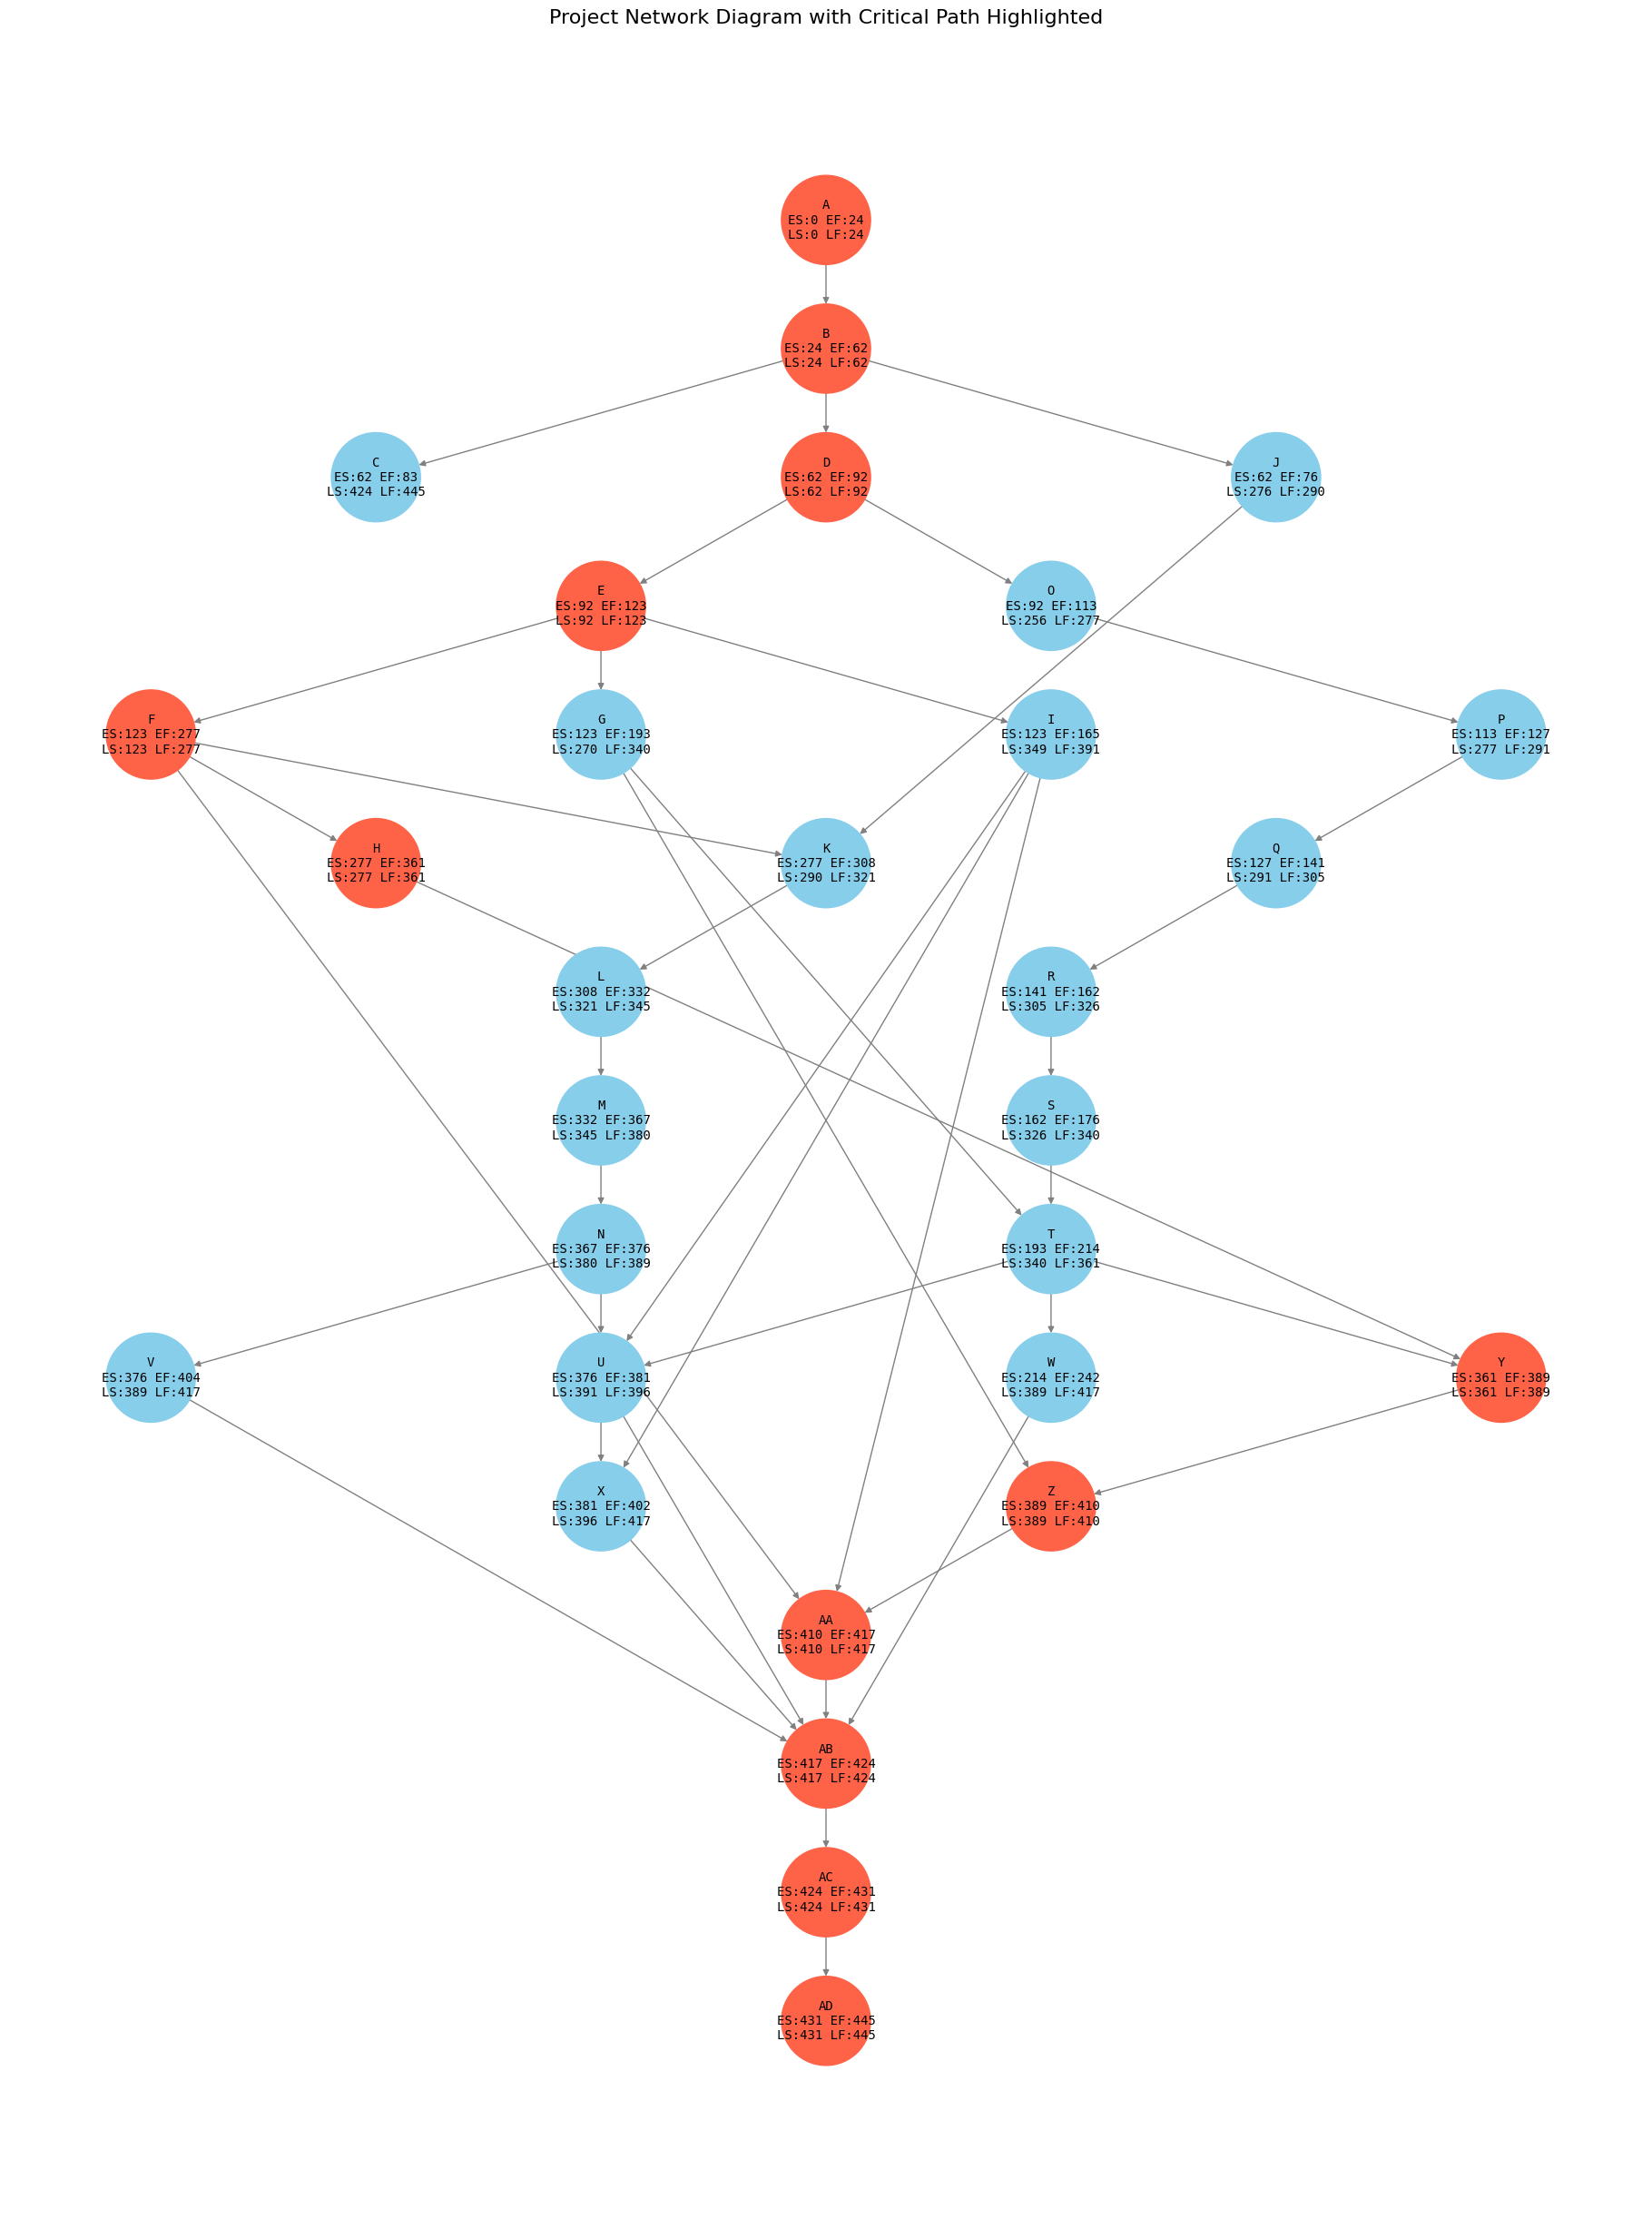

In [5]:
import matplotlib.pyplot as plt

def draw_network_diagram(G, critical_path,filename="network_diagram.png"):
    plt.figure(figsize=(18, 24))
    # pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)
    pos = compute_layered_positions(G)

    # pos = compute_layered_positions(G, layer_gap=3.0, node_gap=14)

    node_colors = ['tomato' if n in critical_path else 'skyblue' for n in G.nodes]
    labels = {
        n: f"{n}\nES:{G.nodes[n]['ES']} EF:{G.nodes[n]['EF']}\nLS:{G.nodes[n]['LS']} LF:{G.nodes[n]['LF']}"
        for n in G.nodes
    }

    # Draw network
    nx.draw(G, pos, with_labels=False, arrows=True, node_size=5000, node_color=node_colors, edge_color='gray')
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_family="monospace")

    # # Optional: draw edge weights if needed
    # edge_labels = {(u, v): '' for u, v in G.edges}
    # nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=20)

    plt.title("Project Network Diagram with Critical Path Highlighted", fontsize=16)
    plt.axis('off')
    plt.tight_layout()


    plt.savefig(filename, dpi=300)
    print(f"Diagram saved as '{filename}'")

    plt.show()

draw_network_diagram(G, critical_path, filename="cpm_diagram.png")


# ACT_CRASHING

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Activity data (same as provided)
data = {
    'Activity ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD'],
    'Activity Name': [
        'Site Assessment', 'Master Plan Development', 'Energy/Water Demand Estimation', 'Feasibility Study', 'Excavation and Earthworks', 'Building Construction',
        'River and Lake Installation', 'Vertical Garden Setup', 'Transportation Facility Construction', 'Solar Panel Site Selection', 'Solar Panel Installation',
        'Inverter and Wiring Setup', 'Battery Storage Integration', 'Grid Connection', 'Water Treatment Plant Design', 'Water Intake System', 'Pre-Treatment Installation',
        'Reverse Osmosis System', 'Post-Treatment and Storage', 'Distribution Network', 'System Integration', 'Initial Testing (Energy)', 'Initial Testing (Water)',
        'Transportation Testing', 'Ecosystem Validation', 'Landscaping and Aesthetics', 'Safety and Accessibility', 'Final Inspections', 'Commissioning', 'Maintenance Plan'
    ],
    'Normal Duration (Days)': [24, 38, 21, 30, 31, 154, 70, 84, 42, 14, 31, 24, 35, 9, 21, 14, 14, 21, 14, 21, 3, 28, 28, 21, 28, 21, 7, 7, 7, 14],
    'Crash Duration (Days)': [14, 28, 14, 21, 24, 140, 56, 70, 35, 10, 24, 14, 28, 7, 14, 10, 10, 14, 10, 17, 3, 21, 21, 17, 24, 14, 5, 6, 6, 12],
    'Direct Costs ($M)': [0.02, 0.1, 0.01, 0.08, 0.2, 500, 1.75, 1, 2, 0.01, 5, 0.1, 0.1, 0.05, 0.08, 0.1, 0.1, 0.15, 0.1, 0.15, 0.2, 0.01, 0.01, 0.01, 0.1, 0.15, 0.01, 0.01, 0.01, 0.01],
    'Overhead/Indirect Costs ($M)': [0.003, 0.015, 0.002, 0.012, 0.03, 75, 0.26, 0.15, 0.3, 0.002, 0.75, 0.015, 0.015, 0.0075, 0.012, 0.015, 0.015, 0.0225, 0.015, 0.0225, 0.03, 0.002, 0.002, 0.002, 0.015, 0.0225, 0.002, 0.002, 0.002, 0.002],
    'Normal Cost ($M)': [0.023, 0.115, 0.012, 0.092, 0.23, 575, 2.01, 1.15, 2.3, 0.012, 5.75, 0.115, 0.115, 0.0575, 0.092, 0.115, 0.115, 0.1725, 0.115, 0.1725, 0.23, 0.012, 0.012, 0.012, 0.115, 0.1725, 0.012, 0.012, 0.012, 0.012],
    'Crash Cost ($M)': [0.025, 0.125, 0.014, 0.102, 0.25, 575.2, 2.03, 1.17, 2.32, 0.014, 5.79, 0.125, 0.125, 0.0625, 0.102, 0.125, 0.125, 0.2025, 0.125, 0.1825, 0.25, 0.014, 0.014, 0.014, 0.125, 0.1825, 0.014, 0.014, 0.014, 0.014],
    'Resource Demand (Workers)': [5, 10, 5, 8, 20, 50, 15, 10, 15, 5, 20, 10, 10, 5, 8, 10, 10, 15, 10, 15, 20, 5, 5, 5, 10, 15, 5, 5, 5, 5]
}



# Create activities dictionary with dependencies
dependencies = {
    'A': [], 'B': ['A'], 'C': ['B'], 'D': ['B'], 'E': ['D'], 'F': ['E'], 'G': ['E'], 'H': ['F'], 'I': ['E'], 'J': ['B'],
    'K': ['J', 'F'], 'L': ['K'], 'M': ['L'], 'N': ['M'], 'O': ['D'], 'P': ['O'], 'Q': ['P'], 'R': ['Q'], 'S': ['R'],
    'T': ['S', 'G'], 'U': ['N', 'T', 'I'], 'V': ['N'], 'W': ['T'], 'X': ['I', 'U'], 'Y': ['T', 'H'], 'Z': ['G', 'Y'],
    'AA': ['F', 'I', 'Z'], 'AB': ['U', 'V', 'W', 'X', 'AA'], 'AC': ['AB'], 'AD': ['AC']
}

# Add 'depends' key to each activity in 'data'
for activity_id in data['Activity ID']:
    data_index = data['Activity ID'].index(activity_id)  # Get index of activity in data
    data['depends'] = data.get('depends', []) + [dependencies[activity_id]]
# Create DataFrame and save to CSV
df = pd.DataFrame(data)
# df.to_csv('activity_cost_details.csv', index=False)

# Calculate crash slope
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / ((df['Normal Duration (Days)'] - df['Crash Duration (Days)'] )) * 1000000).round(2)


activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': dependencies[row['Activity ID']],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in df.iterrows()}



In [7]:
import networkx as nx

# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        G.add_node(act, duration=info['normal_duration'])
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            G.nodes[node]['EF'] = G.nodes[node]['duration']
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    # print(f'end_nodes :{end_nodes}')

    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    return G, critical_path, project_duration
G, critical_path, project_duration = calculate_cpm(activities)
print(f"Project Duration: {project_duration} weeks")
print(f"Critical Path: {critical_path}")

Project Duration: 445 weeks
Critical Path: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']


In [8]:
import pandas as pd

def generate_cost_curve(activities, indirect_cost_savings_per_day=142857 / 1000000, penalty_per_day=50000 / 1000000):
    # Calculate initial CPM data
    G, critical_path, normal_duration = calculate_cpm(activities)
    initial_cost = sum(info['normal_cost'] for info in activities.values())
    original_durations = {act: info['normal_duration'] for act, info in activities.items()}

    # Get least possible duration by fully crashing
    for act in activities:
        activities[act]['normal_duration'] = activities[act]['crash_duration']
    _, _, least_duration = calculate_cpm(activities)

    # Restore normal durations
    for act in activities:
        activities[act]['normal_duration'] = original_durations[act]

    # Initialize tracking variables
    G, critical_path, current_duration = calculate_cpm(activities)
    duration_history = [normal_duration]
    total_cost_history = [initial_cost]
    current_cost = initial_cost
    days_crashed = 0

    optimum_cost = initial_cost
    optimum_duration = normal_duration
    optimum_critical_activities = []
    optimum_activity_durations = {}
    crashing_order = []
    # Crashing loop
    while current_duration > least_duration:
        crashable = [
            (act, activities[act]['crash_slope'])
            for act in critical_path
            if activities[act]['normal_duration'] > activities[act]['crash_duration']
        ]
        if not crashable:
            break

        act_to_crash = min(crashable, key=lambda x: x[1])[0]
        crashing_order.append(act_to_crash)
        crash_days = min(0.5, activities[act_to_crash]['normal_duration'] - activities[act_to_crash]['crash_duration'])

        crash_cost_increase = crash_days * (activities[act_to_crash]['crash_slope'] / 1_000_000)
        indirect_savings = crash_days * indirect_cost_savings_per_day
        penalty = days_crashed * penalty_per_day if days_crashed > 28 else 0

        current_cost += crash_cost_increase - indirect_savings + penalty

        # Check if this is the lowest cost seen so far
        if current_cost < optimum_cost:
            optimum_cost = current_cost
            optimum_duration = current_duration
            optimum_critical_activities = critical_path[:]
            # Save the durations at this point
            optimum_activity_durations = {
                act: activities[act]['normal_duration'] for act in activities
            }

        # Apply crash
        activities[act_to_crash]['normal_duration'] -= crash_days
        days_crashed += crash_days

        # Recalculate CPM
        G, critical_path, current_duration = calculate_cpm(activities)
        duration_history.append(current_duration)
        total_cost_history.append(current_cost)

    # Optional delay simulation (keeping cost same, increasing duration)
    for act in activities:
        activities[act]['normal_duration'] = original_durations[act]
    G, critical_path, current_duration = calculate_cpm(activities)
    while current_duration < normal_duration:
        current_duration += 1
        total_cost_history.append(current_cost)
        duration_history.append(current_duration)

    print(f"Optimum Duration: {optimum_duration} days")
    print(f"Optimum Cost: ${optimum_cost:.2f}M")
    print(f"Critical Activities at Optimum Cost-Duration: {optimum_critical_activities}")

    # Build crash info DataFrame
    crashed_activities = []
    for act in activities:
        normal = original_durations[act]
        crashed = optimum_activity_durations.get(act, normal)
        if crashed < normal:
            crashed_activities.append({
                'Activity': act,
                'Normal Duration': normal,
                'Crashed Duration': crashed,
                'Days Crashed': normal - crashed
            })

    df_crashed = pd.DataFrame(crashed_activities)

    return duration_history, total_cost_history, optimum_duration, optimum_cost, least_duration, initial_cost, normal_duration, df_crashed,crashing_order


Optimum Duration: 417.0 days
Optimum Cost: $584.31M
Critical Activities at Optimum Cost-Duration: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']
Crashing_order_Details_after_crashing: {'A': 20, 'B': 20, 'AA': 4, 'AD': 4, 'D': 18, 'H': 28, 'V': 14, 'Z': 14, 'X': 7, 'L': 15, 'AB': 2, 'AC': 2, 'Y': 8, 'E': 14, 'F': 28}
Normal Duration: 445 days, Normal Cost: $588.36M
Optimum Duration or Least cost duration: 417.0 days, Optimum Cost: $584.31M
Least Duration: 364 days, Least Cost: $1022.20M


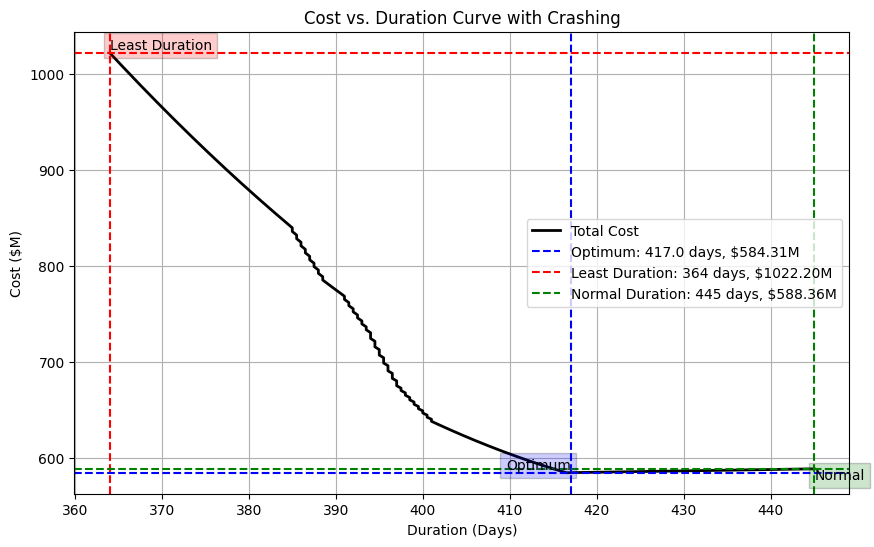

In [9]:
from collections import Counter
# Run curve generation
duration_history, total_cost_history, optimum_duration, optimum_cost, least_duration, initial_cost, normal_duration, df_crashed,crashing_order  = generate_cost_curve(activities) # Added normal_duration to capture the returned value

crashed_dict = Counter(crashing_order)
# Convert counts to crash days
crashed_dict = {act: days for act, days in crashed_dict.items()}
print("Crashing_order_Details_after_crashing:", crashed_dict)


# print("Crashing Order:", crashing_order)  # Print the order
print(f"Normal Duration: {normal_duration} days, Normal Cost: ${initial_cost:.2f}M")
print(f"Optimum Duration or Least cost duration: {optimum_duration} days, Optimum Cost: ${optimum_cost:.2f}M")
print(f"Least Duration: {least_duration} days, Least Cost: ${total_cost_history[duration_history.index(least_duration)]:.2f}M")

# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(duration_history, total_cost_history, 'k-', label='Total Cost', linewidth=2)
plt.axvline(optimum_duration, color='b', linestyle='--', label=f'Optimum: {optimum_duration} days, ${optimum_cost:.2f}M')
plt.axvline(least_duration, color='r', linestyle='--', label=f'Least Duration: {least_duration} days, ${total_cost_history[duration_history.index(least_duration)]:.2f}M')
plt.axvline(normal_duration, color='g', linestyle='--', label=f'Normal Duration: {normal_duration} days, ${initial_cost:.2f}M')
plt.axhline(optimum_cost, color='b', linestyle='--')
plt.axhline(total_cost_history[duration_history.index(least_duration)], color='r', linestyle='--')
plt.axhline(initial_cost, color='g', linestyle='--')
plt.text(optimum_duration, optimum_cost, 'Optimum', bbox=dict(facecolor='blue', alpha=0.2), ha='right', va='bottom')
plt.text(least_duration, total_cost_history[duration_history.index(least_duration)], 'Least Duration', bbox=dict(facecolor='red', alpha=0.2), ha='left', va='bottom')
plt.text(normal_duration, initial_cost, 'Normal', bbox=dict(facecolor='green', alpha=0.2), ha='left', va='top')
plt.xlabel('Duration (Days)')
plt.ylabel('Cost ($M)')
plt.title('Cost vs. Duration Curve with Crashing')
plt.legend()
plt.grid(True)
plt.show()



# Resource leveling


In [10]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Activity data (same as provided)
data = {
    'Activity ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD'],
    'Activity Name': [
        'Site Assessment', 'Master Plan Development', 'Energy/Water Demand Estimation', 'Feasibility Study', 'Excavation and Earthworks', 'Building Construction',
        'River and Lake Installation', 'Vertical Garden Setup', 'Transportation Facility Construction', 'Solar Panel Site Selection', 'Solar Panel Installation',
        'Inverter and Wiring Setup', 'Battery Storage Integration', 'Grid Connection', 'Water Treatment Plant Design', 'Water Intake System', 'Pre-Treatment Installation',
        'Reverse Osmosis System', 'Post-Treatment and Storage', 'Distribution Network', 'System Integration', 'Initial Testing (Energy)', 'Initial Testing (Water)',
        'Transportation Testing', 'Ecosystem Validation', 'Landscaping and Aesthetics', 'Safety and Accessibility', 'Final Inspections', 'Commissioning', 'Maintenance Plan'
    ],
    'Normal Duration (Days)': [24, 38, 21, 30, 31, 154, 70, 84, 42, 14, 31, 24, 35, 9, 21, 14, 14, 21, 14, 21, 3, 28, 28, 21, 28, 21, 7, 7, 7, 14],
    'Crash Duration (Days)': [14, 28, 14, 21, 24, 140, 56, 70, 35, 10, 24, 14, 28, 7, 14, 10, 10, 14, 10, 17, 3, 21, 21, 17, 24, 14, 5, 6, 6, 12],
    'Direct Costs ($M)': [0.02, 0.1, 0.01, 0.08, 0.2, 500, 1.75, 1, 2, 0.01, 5, 0.1, 0.1, 0.05, 0.08, 0.1, 0.1, 0.15, 0.1, 0.15, 0.2, 0.01, 0.01, 0.01, 0.1, 0.15, 0.01, 0.01, 0.01, 0.01],
    'Overhead/Indirect Costs ($M)': [0.003, 0.015, 0.002, 0.012, 0.03, 75, 0.26, 0.15, 0.3, 0.002, 0.75, 0.015, 0.015, 0.0075, 0.012, 0.015, 0.015, 0.0225, 0.015, 0.0225, 0.03, 0.002, 0.002, 0.002, 0.015, 0.0225, 0.002, 0.002, 0.002, 0.002],
    'Normal Cost ($M)': [0.023, 0.115, 0.012, 0.092, 0.23, 575, 2.01, 1.15, 2.3, 0.012, 5.75, 0.115, 0.115, 0.0575, 0.092, 0.115, 0.115, 0.1725, 0.115, 0.1725, 0.23, 0.012, 0.012, 0.012, 0.115, 0.1725, 0.012, 0.012, 0.012, 0.012],
    'Crash Cost ($M)': [0.025, 0.125, 0.014, 0.102, 0.25, 575.2, 2.03, 1.17, 2.32, 0.014, 5.79, 0.125, 0.125, 0.0625, 0.102, 0.125, 0.125, 0.2025, 0.125, 0.1825, 0.25, 0.014, 0.014, 0.014, 0.125, 0.1825, 0.014, 0.014, 0.014, 0.014],
    'Resource Demand (Workers)': [5, 10, 5, 8, 20, 50, 15, 10, 15, 5, 20, 10, 10, 5, 8, 10, 10, 15, 10, 15, 20, 5, 5, 5, 10, 15, 5, 5, 5, 5]
}



# Create activities dictionary with dependencies
dependencies = {
    'A': [], 'B': ['A'], 'C': ['B'], 'D': ['B'], 'E': ['D'], 'F': ['E'], 'G': ['E'], 'H': ['F'], 'I': ['E'], 'J': ['B'],
    'K': ['J', 'F'], 'L': ['K'], 'M': ['L'], 'N': ['M'], 'O': ['D'], 'P': ['O'], 'Q': ['P'], 'R': ['Q'], 'S': ['R'],
    'T': ['S', 'G'], 'U': ['N', 'T', 'I'], 'V': ['N'], 'W': ['T'], 'X': ['I', 'U'], 'Y': ['T', 'H'], 'Z': ['G', 'Y'],
    'AA': ['F', 'I', 'Z'], 'AB': ['U', 'V', 'W', 'X', 'AA'], 'AC': ['AB'], 'AD': ['AC']
}

# Add 'depends' key to each activity in 'data'
for activity_id in data['Activity ID']:
    data_index = data['Activity ID'].index(activity_id)  # Get index of activity in data
    data['depends'] = data.get('depends', []) + [dependencies[activity_id]]
# Create DataFrame and save to CSV
df = pd.DataFrame(data)
df.to_csv('activity_cost_details.csv', index=False)

# Calculate crash slope
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / ((df['Normal Duration (Days)'] - df['Crash Duration (Days)'] )) * 1000000).round(2)


activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': dependencies[row['Activity ID']],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in df.iterrows()}



In [11]:
# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        G.add_node(act, duration=info['normal_duration'], resources=info['resources'])
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            G.nodes[node]['EF'] = G.nodes[node]['duration']
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    # print(f'end_nodes: {end_nodes}')
    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    return G, critical_path, project_duration



Histogram of activties and time

Histogram saved as 'activity_histogram.png'


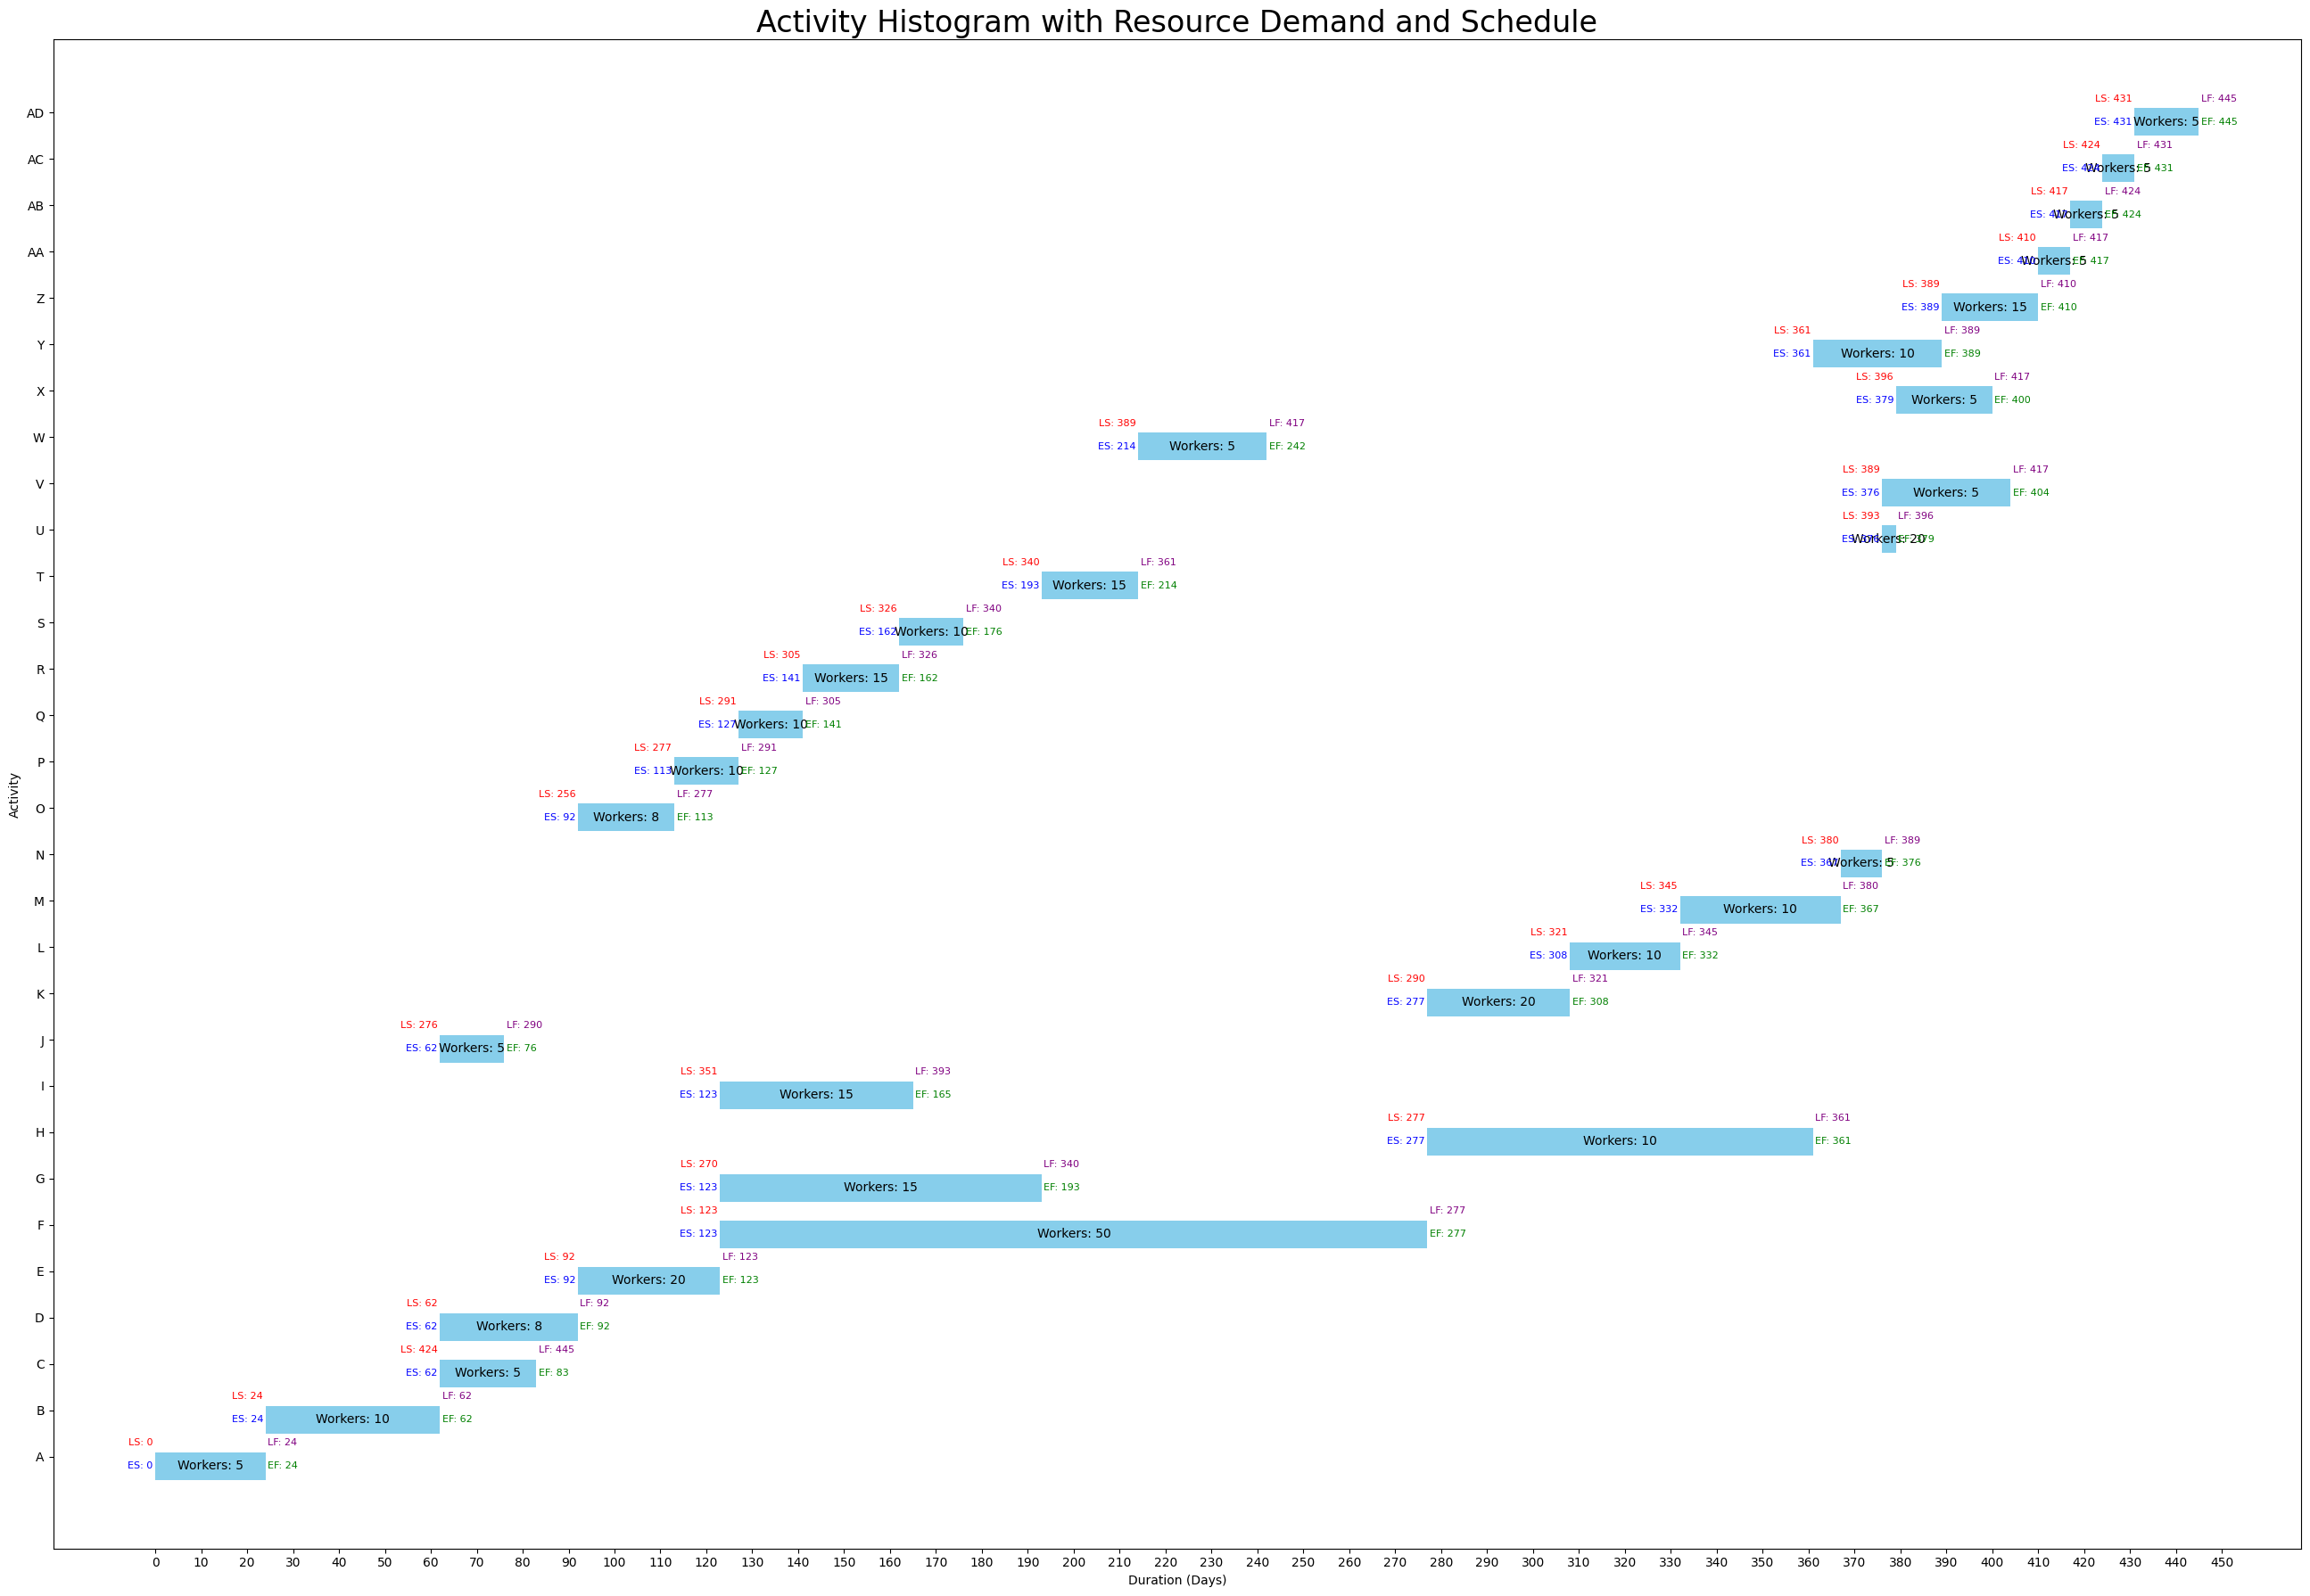

In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_activity_histogram(activities, G,filename="activity_histogram.png"):
    # Data for plotting
    activity_names = list(activities.keys())
    durations = [G.nodes[act]['duration'] for act in activity_names]
    es_values = [G.nodes[act]['ES'] for act in activity_names]
    ef_values = [G.nodes[act]['EF'] for act in activity_names]
    ls_values = [G.nodes[act]['LS'] for act in activity_names]
    lf_values = [G.nodes[act]['LF'] for act in activity_names]
    resources = [activities[act]['resources'] for act in activity_names]


    xranges = [[(es, ef - es)] for es, ef in zip(es_values, ef_values)]
    # yrange = [(i * 1, 0.8) for i in range(len(activity_names))] #The original yrange is a list of tuples which caused the issue
    # Modified yrange to a list of tuples with a single tuple for each activity.
    yrange = [(i * 1, 0.6) for i in range(len(activity_names))]

    # Create the histogram
    fig, ax = plt.subplots(figsize=(26, 18))

    # Iterate over xranges and yrange to plot individual bars
    for i in range(len(activity_names)):
        ax.broken_barh(xranges[i], yrange[i], facecolors='skyblue') #Pass each tuple individually to broken_barh


    # Add resource demand as text within bars
    for i, resource in enumerate(resources):
        ax.text(xranges[i][0][0] + xranges[i][0][1] / 2, yrange[i][0] + yrange[i][1] / 2,
                f"Workers: {resource}", ha='center', va='center', color='black')

    # Add ES, EF, LS, LF as text annotations
    for i, (es, ef, ls, lf) in enumerate(zip(es_values, ef_values, ls_values, lf_values)):
        ax.text(es - 0.5, yrange[i][0] + yrange[i][1] / 2, f"ES: {es}", ha='right', va='center', fontsize=8, color='blue')
        ax.text(ef + 0.5, yrange[i][0] + yrange[i][1] / 2, f"EF: {ef}", ha='left', va='center', fontsize=8, color='green')
        ax.text(es - 0.5, yrange[i][0] + yrange[i][1] / 2 + 0.5, f"LS: {ls}", ha='right', va='center', fontsize=8, color='red')
        ax.text(ef + 0.5, yrange[i][0] + yrange[i][1] / 2 + 0.5, f"LF: {lf}", ha='left', va='center', fontsize=8, color='purple')


    max_duration = max(ef_values)
    ax.set_xticks(np.arange(0, max_duration + 10, 10))  # Ticks every 10 days
    ax.set_xlabel("Duration (Days)")

    # Set y-axis ticks and labels
    ax.set_yticks(np.arange(0.5, len(activity_names), 1))  # Centered on bars
    ax.set_yticklabels(activity_names)
    ax.set_ylabel("Activity")
    # Chart formatting

    ax.set_xlabel("Duration (Days)")
    ax.set_ylabel("Activity")
    ax.set_title("Activity Histogram with Resource Demand and Schedule",fontsize=24)
    plt.tight_layout()

    plt.savefig(filename, dpi=300)  # Save the figure
    print(f"Histogram saved as '{filename}'")  # Print confirmation

    plt.show()


G, critical_path, project_duration = calculate_cpm(activities) # Assuming calculate_cpm is defined
plot_activity_histogram(activities, G)



Resource usage before leveling

Project Duration: 445 days
Critical Path: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']


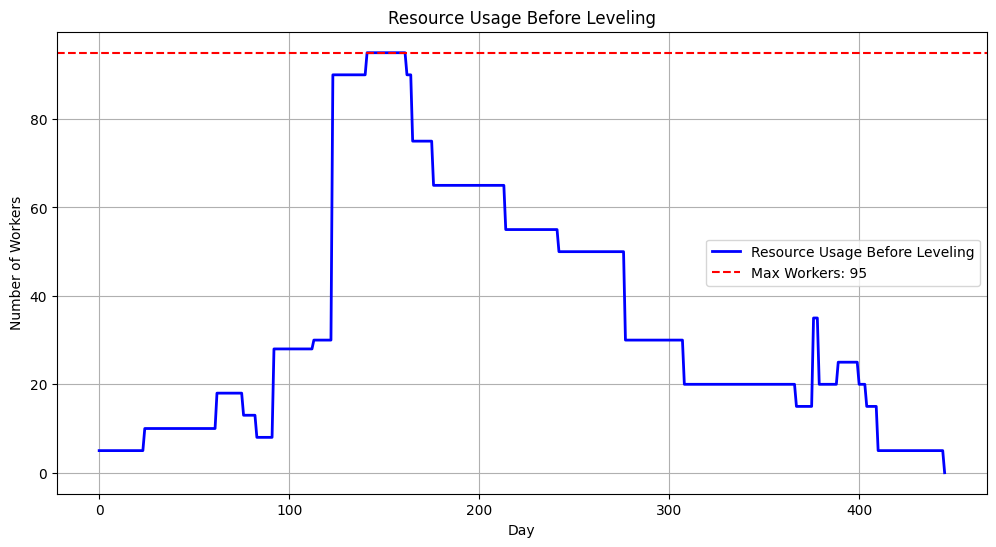

In [13]:
# Calculate resource usage before leveling
def resource_usage_before_leveling(G, activities):
    max_duration = max(G.nodes[n]['EF'] for n in G.nodes)
    resource_profile = [0] * (max_duration + 1)
    for act in activities:
        es = G.nodes[act]['ES']
        ef = G.nodes[act]['EF']
        resources = activities[act]['resources']
        for day in range(es, ef):
            resource_profile[day] += resources
    return resource_profile

# Run CPM and get resource profile before leveling
G, critical_path, project_duration = calculate_cpm(activities)
print(f"Project Duration: {project_duration} days")
print(f"Critical Path: {critical_path}")
resource_profile_before = resource_usage_before_leveling(G, activities)

# Plot resource usage before leveling
plt.figure(figsize=(12, 6))
plt.plot(range(len(resource_profile_before)), resource_profile_before, 'b-', label='Resource Usage Before Leveling', linewidth=2)
plt.axhline(max(resource_profile_before), color='r', linestyle='--', label=f'Max Workers: {max(resource_profile_before)}')
plt.xlabel('Day')
plt.ylabel('Number of Workers')
plt.title('Resource Usage Before Leveling')
plt.legend()
plt.grid(True)
plt.show()

# discussion


New Project Duration: 445 days


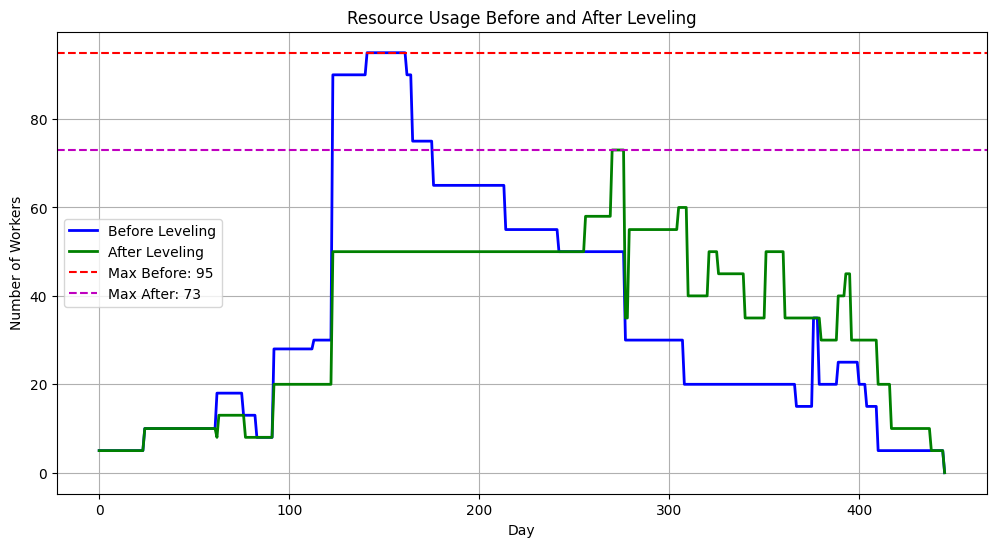

Resource Leveling:
   - Before resource leveling, the maximum resource demand was: 95 workers
   - After resource leveling, the maximum resource demand is reduced to: 73 workers
   - This reduction in peak resource demand was achieved by strategically shifting non-critical activities within their available float (slack).
   - By delaying the start of certain non-critical activities, resource usage was spread out more evenly over time.
   - This prevented the concentration of resource demand at specific periods, which would have required a larger workforce.
   - The leveling process ensured that the project could be completed with a smaller maximum workforce of 60 workers without extending the project duration.
   - This leads to better resource allocation, cost savings, and improved project feasibility.


In [14]:

import numpy as np

# Resource leveling function
def resource_leveling(activities, G, max_resources=60):
    leveled_activities = activities.copy()
    # Calculate float for each activity
    for act in leveled_activities:
        ef = G.nodes[act]['EF']
        lf = G.nodes[act]['LF']
        leveled_activities[act]['float'] = lf - ef

    # Level resources by delaying non-critical activities
    new_G = nx.DiGraph()
    for act, info in leveled_activities.items():
        new_G.add_node(act, duration=info['normal_duration'], resources=info['resources'])
        for dep in info['depends']:
            new_G.add_edge(dep, act)

    # Initial ES and EF
    for node in nx.topological_sort(new_G):
        predecessors = list(new_G.predecessors(node))
        if not predecessors:
            new_G.nodes[node]['ES'] = 0
            new_G.nodes[node]['EF'] = new_G.nodes[node]['duration']
        else:
            new_G.nodes[node]['ES'] = max(new_G.nodes[pred]['EF'] for pred in predecessors)
            new_G.nodes[node]['EF'] = new_G.nodes[node]['ES'] + new_G.nodes[node]['duration']

    # Calculate initial LF and LS before adjusting (This is the key fix)
    end_nodes = [n for n, d in new_G.out_degree() if d == 0]
    project_duration = max(new_G.nodes[n]['EF'] for n in end_nodes)
    for node in reversed(list(nx.topological_sort(new_G))):
        successors = list(new_G.successors(node))
        if not successors:
            new_G.nodes[node]['LF'] = project_duration
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']
        else:
            new_G.nodes[node]['LF'] = min(new_G.nodes[succ]['LS'] for succ in successors)
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']

    # Adjust non-critical activities
    changed = True


# New logic inside the while loop
    while changed:
        changed = False
        resource_profile = resource_usage_before_leveling(new_G, leveled_activities)
        variance_before = np.var(resource_profile)

        # Try delaying non-critical activities with float > 0
        for act in sorted(leveled_activities, key=lambda x: -leveled_activities[x]['float']):  # Higher float first
            if leveled_activities[act]['float'] > 0:
                current_es = new_G.nodes[act]['ES']
                max_delay = leveled_activities[act]['float']
                best_es = current_es
                best_variance = variance_before

                for delay in range(1, max_delay + 1):
                    trial_es = current_es + delay
                    if trial_es > new_G.nodes[act]['LF'] - new_G.nodes[act]['duration']:
                        continue

                    # Temporarily shift activity
                    temp_G = new_G.copy()
                    temp_G.nodes[act]['ES'] = trial_es
                    temp_G.nodes[act]['EF'] = trial_es + temp_G.nodes[act]['duration']

                    # Shift successors
                    for succ in nx.descendants(temp_G, act):
                        preds = list(temp_G.predecessors(succ))
                        temp_G.nodes[succ]['ES'] = max(temp_G.nodes[p]['EF'] for p in preds)
                        temp_G.nodes[succ]['EF'] = temp_G.nodes[succ]['ES'] + temp_G.nodes[succ]['duration']

                    # Recalculate resource profile
                    temp_profile = resource_usage_after_leveling(temp_G, leveled_activities)
                    temp_variance = np.var(temp_profile)

                    if temp_variance < best_variance:
                        best_es = trial_es
                        best_variance = temp_variance
                        changed = True

                if best_es != current_es:
                    new_G.nodes[act]['ES'] = best_es
                    new_G.nodes[act]['EF'] = best_es + new_G.nodes[act]['duration']
                    for succ in nx.descendants(new_G, act):
                        preds = list(new_G.predecessors(succ))
                        new_G.nodes[succ]['ES'] = max(new_G.nodes[p]['EF'] for p in preds)
                        new_G.nodes[succ]['EF'] = new_G.nodes[succ]['ES'] + new_G.nodes[succ]['duration']

        if not changed:
            break


    # Recalculate backward pass to ensure feasibility
    end_nodes = [n for n, d in new_G.out_degree() if d == 0]
    project_duration = max(new_G.nodes[n]['EF'] for n in end_nodes)
    for node in reversed(list(nx.topological_sort(new_G))):
        successors = list(new_G.successors(node))
        if not successors:
            new_G.nodes[node]['LF'] = project_duration
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']
        else:
            new_G.nodes[node]['LF'] = min(new_G.nodes[succ]['LS'] for succ in successors)
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']

    return new_G, project_duration

# Calculate resource usage after leveling
def resource_usage_after_leveling(new_G, activities):
    max_duration = max(new_G.nodes[n]['EF'] for n in new_G.nodes)
    resource_profile = [0] * (max_duration + 1)
    for act in activities:
        es = new_G.nodes[act]['ES']
        ef = new_G.nodes[act]['EF']
        resources = activities[act]['resources']
        for day in range(es, ef):
            resource_profile[day] += resources
    return resource_profile

# Perform leveling and get new profiles
new_G, new_project_duration = resource_leveling(activities, G)
resource_profile_after = resource_usage_after_leveling(new_G, activities)
print(f"New Project Duration: {new_project_duration} days")

# Plot both resource usages
plt.figure(figsize=(12, 6))
plt.plot(range(len(resource_profile_before)), resource_profile_before, 'b-', label='Before Leveling', linewidth=2)
plt.plot(range(len(resource_profile_after)), resource_profile_after, 'g-', label='After Leveling', linewidth=2)
plt.axhline(max(resource_profile_before), color='r', linestyle='--', label=f'Max Before: {max(resource_profile_before)}')
plt.axhline(max(resource_profile_after), color='m', linestyle='--', label=f'Max After: {max(resource_profile_after)}')
plt.xlabel('Day')
plt.ylabel('Number of Workers')
plt.title('Resource Usage Before and After Leveling')
plt.legend()
plt.grid(True)
plt.show()

#  Resource Leveling:
print("Resource Leveling:")
print(f"   - Before resource leveling, the maximum resource demand was: {max(resource_profile_before)} workers")
print(f"   - After resource leveling, the maximum resource demand is reduced to: {max(resource_profile_after)} workers")
print("   - This reduction in peak resource demand was achieved by strategically shifting non-critical activities within their available float (slack).")
print("   - By delaying the start of certain non-critical activities, resource usage was spread out more evenly over time.")
print("   - This prevented the concentration of resource demand at specific periods, which would have required a larger workforce.")
print("   - The leveling process ensured that the project could be completed with a smaller maximum workforce of 60 workers without extending the project duration.")
print("   - This leads to better resource allocation, cost savings, and improved project feasibility.")

# PROGRESS UPDATES AND EARNED VALUE ANALYSIS

In [32]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Activity data (same as provided)
data = {
    'Activity ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD'],
    'Activity Name': [
        'Site Assessment', 'Master Plan Development', 'Energy/Water Demand Estimation', 'Feasibility Study', 'Excavation and Earthworks', 'Building Construction',
        'River and Lake Installation', 'Vertical Garden Setup', 'Transportation Facility Construction', 'Solar Panel Site Selection', 'Solar Panel Installation',
        'Inverter and Wiring Setup', 'Battery Storage Integration', 'Grid Connection', 'Water Treatment Plant Design', 'Water Intake System', 'Pre-Treatment Installation',
        'Reverse Osmosis System', 'Post-Treatment and Storage', 'Distribution Network', 'System Integration', 'Initial Testing (Energy)', 'Initial Testing (Water)',
        'Transportation Testing', 'Ecosystem Validation', 'Landscaping and Aesthetics', 'Safety and Accessibility', 'Final Inspections', 'Commissioning', 'Maintenance Plan'
    ],
    'Normal Duration (Days)': [24, 38, 21, 30, 31, 154, 70, 84, 42, 14, 31, 24, 35, 9, 21, 14, 14, 21, 14, 21, 3, 28, 28, 21, 28, 21, 7, 7, 7, 14],
    'Crash Duration (Days)': [14, 28, 14, 21, 24, 140, 56, 70, 35, 10, 24, 14, 28, 7, 14, 10, 10, 14, 10, 17, 3, 21, 21, 17, 24, 14, 5, 6, 6, 12],
    'Direct Costs ($M)': [0.02, 0.1, 0.01, 0.08, 0.2, 500, 1.75, 1, 2, 0.01, 5, 0.1, 0.1, 0.05, 0.08, 0.1, 0.1, 0.15, 0.1, 0.15, 0.2, 0.01, 0.01, 0.01, 0.1, 0.15, 0.01, 0.01, 0.01, 0.01],
    'Overhead/Indirect Costs ($M)': [0.003, 0.015, 0.002, 0.012, 0.03, 75, 0.26, 0.15, 0.3, 0.002, 0.75, 0.015, 0.015, 0.0075, 0.012, 0.015, 0.015, 0.0225, 0.015, 0.0225, 0.03, 0.002, 0.002, 0.002, 0.015, 0.0225, 0.002, 0.002, 0.002, 0.002],
    'Normal Cost ($M)': [0.023, 0.115, 0.012, 0.092, 0.23, 575, 2.01, 1.15, 2.3, 0.012, 5.75, 0.115, 0.115, 0.0575, 0.092, 0.115, 0.115, 0.1725, 0.115, 0.1725, 0.23, 0.012, 0.012, 0.012, 0.115, 0.1725, 0.012, 0.012, 0.012, 0.012],
    'Crash Cost ($M)': [0.025, 0.125, 0.014, 0.102, 0.25, 575.2, 2.03, 1.17, 2.32, 0.014, 5.79, 0.125, 0.125, 0.0625, 0.102, 0.125, 0.125, 0.2025, 0.125, 0.1825, 0.25, 0.014, 0.014, 0.014, 0.125, 0.1825, 0.014, 0.014, 0.014, 0.014],
    'Resource Demand (Workers)': [5, 10, 5, 8, 20, 50, 15, 10, 15, 5, 20, 10, 10, 5, 8, 10, 10, 15, 10, 15, 20, 5, 5, 5, 10, 15, 5, 5, 5, 5]
}



# Create activities dictionary with dependencies
dependencies = {
    'A': [], 'B': ['A'], 'C': ['B'], 'D': ['B'], 'E': ['D'], 'F': ['E'], 'G': ['E'], 'H': ['F'], 'I': ['E'], 'J': ['B'],
    'K': ['J', 'F'], 'L': ['K'], 'M': ['L'], 'N': ['M'], 'O': ['D'], 'P': ['O'], 'Q': ['P'], 'R': ['Q'], 'S': ['R'],
    'T': ['S', 'G'], 'U': ['N', 'T', 'I'], 'V': ['N'], 'W': ['T'], 'X': ['I', 'U'], 'Y': ['T', 'H'], 'Z': ['G', 'Y'],
    'AA': ['F', 'I', 'Z'], 'AB': ['U', 'V', 'W', 'X', 'AA'], 'AC': ['AB'], 'AD': ['AC']
}

# Add 'depends' key to each activity in 'data'
for activity_id in data['Activity ID']:
    data_index = data['Activity ID'].index(activity_id)  # Get index of activity in data
    data['depends'] = data.get('depends', []) + [dependencies[activity_id]]
# Create DataFrame and save to CSV
df = pd.DataFrame(data)
df.to_csv('activity_cost_details.csv', index=False)

# Calculate crash slope
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / ((df['Normal Duration (Days)'] - df['Crash Duration (Days)'] )) * 1000000).round(2)


activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': dependencies[row['Activity ID']],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in df.iterrows()}


# Apply delay to activity F
activities['F']['normal_duration'] += 5
print("Applied 5-day delay to activity F.")
total_delay = 5



Applied 5-day delay to activity F.


In [33]:
import networkx as nx

# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        G.add_node(act, duration=info['normal_duration'])
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            G.nodes[node]['EF'] = G.nodes[node]['duration']
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    # print(f'end_nodes :{end_nodes}')

    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    return G, critical_path, project_duration
G, critical_path, project_duration = calculate_cpm(activities)
print(f"Project Duration: {project_duration} weeks")
print(f"Critical Path: {critical_path}")

Project Duration: 450 weeks
Critical Path: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']


In [34]:
import pandas as pd

def generate_cost_curve(activities, indirect_cost_savings_per_day=142857 / 1000000, penalty_per_day=50000 / 1000000):
    # Calculate initial CPM data
    G, critical_path, normal_duration = calculate_cpm(activities)
    initial_cost = sum(info['normal_cost'] for info in activities.values())
    original_durations = {act: info['normal_duration'] for act, info in activities.items()}

    # Get least possible duration by fully crashing
    for act in activities:
        activities[act]['normal_duration'] = activities[act]['crash_duration']
    _, _, least_duration = calculate_cpm(activities)

    # Restore normal durations
    for act in activities:
        activities[act]['normal_duration'] = original_durations[act]

    # Initialize tracking variables
    G, critical_path, current_duration = calculate_cpm(activities)
    duration_history = [normal_duration]
    total_cost_history = [initial_cost]
    current_cost = initial_cost
    days_crashed = 0

    optimum_cost = initial_cost
    optimum_duration = normal_duration
    optimum_critical_activities = []
    optimum_activity_durations = {}
    crashing_order = []
    # Crashing loop
    while current_duration > least_duration:
        crashable = [
            (act, activities[act]['crash_slope'])
            for act in critical_path
            if activities[act]['normal_duration'] > activities[act]['crash_duration']
        ]
        if not crashable:
            break

        act_to_crash = min(crashable, key=lambda x: x[1])[0]
        crashing_order.append(act_to_crash)
        crash_days = min(0.5, activities[act_to_crash]['normal_duration'] - activities[act_to_crash]['crash_duration'])

        crash_cost_increase = crash_days * (activities[act_to_crash]['crash_slope'] / 1_000_000)
        indirect_savings = crash_days * indirect_cost_savings_per_day
        penalty = days_crashed * penalty_per_day if days_crashed > 28 else 0

        current_cost += crash_cost_increase - indirect_savings + penalty

        # Check if this is the lowest cost seen so far
        if current_cost < optimum_cost:
            optimum_cost = current_cost
            optimum_duration = current_duration
            optimum_critical_activities = critical_path[:]
            # Save the durations at this point
            optimum_activity_durations = {
                act: activities[act]['normal_duration'] for act in activities
            }

        # Apply crash
        activities[act_to_crash]['normal_duration'] -= crash_days
        days_crashed += crash_days

        # Recalculate CPM
        G, critical_path, current_duration = calculate_cpm(activities)
        duration_history.append(current_duration)
        total_cost_history.append(current_cost)

    # Optional delay simulation (keeping cost same, increasing duration)
    for act in activities:
        activities[act]['normal_duration'] = original_durations[act]
    G, critical_path, current_duration = calculate_cpm(activities)
    while current_duration < normal_duration:
        current_duration += 1
        total_cost_history.append(current_cost)
        duration_history.append(current_duration)

    print(f"Optimum Duration: {optimum_duration} days")
    print(f"Optimum Cost: ${optimum_cost:.2f}M")
    print(f"Critical Activities at Optimum Cost-Duration: {optimum_critical_activities}")

    # Build crash info DataFrame
    crashed_activities = []
    for act in activities:
        normal = original_durations[act]
        crashed = optimum_activity_durations.get(act, normal)
        if crashed < normal:
            crashed_activities.append({
                'Activity': act,
                'Normal Duration': normal,
                'Crashed Duration': crashed,
                'Days Crashed': normal - crashed
            })

    df_crashed = pd.DataFrame(crashed_activities)

    return duration_history, total_cost_history, optimum_duration, optimum_cost, least_duration, initial_cost, normal_duration, df_crashed,crashing_order
duration_history, total_cost_history, optimum_duration, optimum_cost, least_duration, initial_cost, normal_duration, df_crashed,crashing_order  = generate_cost_curve(activities)

Optimum Duration: 422.0 days
Optimum Cost: $584.31M
Critical Activities at Optimum Cost-Duration: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']


## progress updates


In [40]:
try:
    df = pd.read_csv("activity_cost_details.csv")
except FileNotFoundError:
    print("Error: activity_cost_details.csv not found. Using sample data.")

# Assign the calculated crash slope back to the original DataFrame (df)
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / (df['Normal Duration (Days)'] - df['Crash Duration (Days)'])) * 1000000
df['Crash Slope ($/Day)'] = df['Crash Slope ($/Day)'].round(2)

# Save the updated DataFrame to the CSV file
df.to_csv('activity_cost_details.csv', index=False)

In [55]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import networkx as nx
from datetime import datetime, timedelta
import ast

# Load activity data
try:
    activity_df = pd.read_csv("activity_cost_details.csv")
except FileNotFoundError:
    print("Error: activity_cost_details.csv not found.")
    exit()

# Process dependencies and calculate crash slope
activity_df['depends'] = activity_df['depends'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x if pd.notna(x) else []
)
activity_df['Crash Slope ($/Day)'] = (
    ((activity_df['Crash Cost ($M)'] - activity_df['Normal Cost ($M)']) /
     (activity_df['Normal Duration (Days)'] - activity_df['Crash Duration (Days)'])) * 1000000
).round(2)

# Create activities dictionary
activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': row['depends'],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in activity_df.iterrows()}



# CPM calculation
def calculate_cpm(activities, project_start_date):
    G = nx.DiGraph()
    for act_id, props in activities.items():
        G.add_node(act_id, duration=props['normal_duration'], ES=0, EF=0, LS=0, LF=0)
        for pred in props.get('depends', []):
            if pred in activities:
                G.add_edge(pred, act_id)
            else:
                print(f"Warning: Predecessor {pred} for activity {act_id} not found.")
    
    if not nx.is_directed_acyclic_graph(G):
        print("Error: Dependency graph contains cycles.")
        return G, [], 0, {}, {}
    
    # Forward pass
    early_start = {}
    early_finish = {}
    for node in nx.topological_sort(G):
        max_es = max([G.nodes[pred]['EF'] for pred in G.predecessors(node)], default=0)
        G.nodes[node]['ES'] = max_es
        G.nodes[node]['EF'] = max_es + G.nodes[node]['duration']
        early_start[node] = project_start_date + pd.Timedelta(days=G.nodes[node]['ES'])
        early_finish[node] = project_start_date + pd.Timedelta(days=G.nodes[node]['EF'])
    
    project_duration = max(G.nodes[node]['EF'] for node in G.nodes) if G.nodes else 0
    
    # Backward pass
    for node in G.nodes:
        G.nodes[node]['LF'] = project_duration
    for node in reversed(list(nx.topological_sort(G))):
        min_ls = min([G.nodes[succ]['LS'] for succ in G.successors(node)], default=project_duration)
        G.nodes[node]['LF'] = min_ls
        G.nodes[node]['LS'] = min_ls - G.nodes[node]['duration']
    
    critical_path = [node for node in G.nodes if G.nodes[node]['ES'] == G.nodes[node]['LS']]
    return G, critical_path, project_duration, early_start, early_finish

# Generate progress update
def generate_progress_update(update_date, completed_activities, started_activities, activity_df, project_start_date):
    update_date = pd.to_datetime(update_date)
    progress_df = activity_df.copy()
    progress_df['Status'] = 'Not Started'
    progress_df['Update Date'] = update_date
    progress_df['early_start'] = pd.NaT
    progress_df['early_finish'] = pd.NaT
    progress_df['duration_days'] = progress_df['Normal Duration (Days)']
    
    # Update duration for delayed activities
    for act_id in activities:
        progress_df.loc[progress_df['Activity ID'] == act_id, 'duration_days'] = activities[act_id]['normal_duration']
    
    # Calculate CPM dates
    G, critical_path, project_duration, early_start_cpm, early_finish_cpm = calculate_cpm(activities, project_start_date)
    
    # Validate completed activities
    for act_id in completed_activities:
        if act_id not in progress_df['Activity ID'].values:
            print(f"Error: Activity {act_id} not found in activity data.")
            return None
        depends = progress_df.loc[progress_df['Activity ID'] == act_id, 'depends'].iloc[0]
        for pred in depends:
            if pred not in completed_activities and pred not in started_activities:
                print(f"Error: Activity {act_id} cannot be completed; predecessor {pred} is not started or completed.")
                return None
    
    # Set initial early start and finish dates based on CPM
    for idx, row in progress_df.iterrows():
        act_id = row['Activity ID']
        if act_id in early_start_cpm:
            progress_df.loc[idx, 'early_start'] = early_start_cpm[act_id]
            progress_df.loc[idx, 'early_finish'] = early_finish_cpm[act_id]
    
    # Adjust dates based on status
    for idx, row in progress_df.iterrows():
        act_id = row['Activity ID']
        duration = row['duration_days']
        if act_id in completed_activities:
            progress_df.loc[idx, 'Status'] = 'Completed'
            progress_df.loc[idx, 'early_finish'] = update_date
            progress_df.loc[idx, 'early_start'] = update_date - pd.Timedelta(days=duration)
            if progress_df.loc[idx, 'early_start'] < project_start_date:
                progress_df.loc[idx, 'early_start'] = project_start_date
        elif act_id in started_activities:
            progress_df.loc[idx, 'Status'] = 'Started'
            if pd.isna(row['early_start']) or row['early_start'] > update_date:
                progress_df.loc[idx, 'early_start'] = update_date
                progress_df.loc[idx, 'early_finish'] = update_date + pd.Timedelta(days=duration)
        elif pd.notna(row['early_start']) and update_date >= row['early_start']:
            depends = row['depends']
            if depends and all(pred in completed_activities for pred in depends):
                progress_df.loc[idx, 'Status'] = 'Started'
    
    return progress_df

# Calculate EVA
def calculate_eva(progress_df, update_date, project_start_date, actual_costs=None, completion_percentages=None):
    update_date = pd.to_datetime(update_date)
    project_start_date = pd.to_datetime(project_start_date)
    pv, ev, ac = 0.0, 0.0, 0.0
    
    # Initialize completion percentages
    if completion_percentages is None:
        completion_percentages = {row['Activity ID']: 0.0 for _, row in progress_df.iterrows()}
    else:
        for act_id in progress_df['Activity ID']:
            if act_id not in completion_percentages:
                completion_percentages[act_id] = 0.0
    
    # Calculate PV, EV, AC for each activity
    for _, row in progress_df.iterrows():
        planned_cost = row['Normal Cost ($M)']
        activity_id = row['Activity ID']
        es = pd.to_datetime(row['early_start']) if pd.notna(row['early_start']) else None
        ef = pd.to_datetime(row['early_finish']) if pd.notna(row['early_finish']) else None
        duration_days = row['duration_days']
        status = row['Status']
        
        # Planned Value (PV) - Histogram-based
        if pd.isna(es) or pd.isna(ef) or duration_days <= 0:
            planned_progress = 0.0
            print(f"Warning: Invalid schedule data for activity {activity_id}. Setting PV to 0.")
        elif update_date < es:
            planned_progress = 0.0
        elif update_date >= ef:
            planned_progress = 1.0
        else:
            days_progressed = (update_date - es).days
            planned_progress = min(days_progressed / duration_days, 1.0)
        pv += planned_cost * planned_progress
        
        # Earned Value (EV)
        if status == 'Completed':
            completion_percentages[activity_id] = 100.0
            ev += planned_cost
        else:
            percent = completion_percentages[activity_id]
            if not (0 <= percent <= 100):
                print(f"Warning: Invalid completion percentage {percent} for activity {activity_id}. Setting to 0.")
                percent = 0.0
                completion_percentages[activity_id] = 0.0
            ev += planned_cost * (percent / 100.0)
        
        # Actual Cost (AC)
        if actual_costs and activity_id in actual_costs and status in ['Completed', 'Started']:
            ac += actual_costs[activity_id]
        elif status in ['Completed', 'Started']:
            print(f"Warning: No actual cost provided for activity {activity_id} in status {status}.")
            
    cv = ev - ac
    sv = ev - pv
    cpi = ev / ac if ac > 0 else float('inf')
    spi = ev / pv if pv > 0 else float('inf')
    
    return {
        'Planned Value (PV)': pv,
        'Earned Value (EV)': ev,
        'Actual Cost (AC)': ac,
        'Cost Variance (CV)': cv,
        'Schedule Variance (SV)': sv,
        'Cost Performance Index (CPI)': cpi,
        'Schedule Performance Index (SPI)': spi
    }
# Plot progress bar chart
def plot_progress_bar(progress_df, update_date, filename):
    
    plt.figure(figsize=(12, 8))
    status_values = progress_df['Status'].map({'Completed': 100, 'Started': 50, 'Not Started': 0})
    colors = progress_df['Status'].map({'Completed': 'green', 'Started': 'blue', 'Not Started': 'grey'})
    bars = plt.bar(progress_df['Activity ID'], status_values, color=colors)
    plt.xlabel('Activity ID')
    plt.ylabel('Progress Status')
    plt.title(f'Activity Progress: {pd.to_datetime(update_date).strftime("%Y-%m-%d")}')
    plt.xticks(rotation=45)
    plt.yticks([0,50, 100], ['Not Started', 'Started', 'Completed'])
    plt.grid(True, axis='y')
    
    for bar, status in zip(bars, progress_df['Status']):
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, status, ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# Plot EVM bar chart
def plot_evm_bar(eva_metrics, update_date, filename):
    metrics = ['Planned Value (PV)', 'Earned Value (EV)', 'Actual Cost (AC)']
    values = [eva_metrics[m] for m in metrics]
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(metrics, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.title(f'EVM Metrics: {pd.to_datetime(update_date).strftime("%Y-%m-%d")}')
    plt.ylabel('Cost ($M)')
    plt.grid(True, axis='y')
    
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, value, f'{value:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# Plot EVM trends
def plot_evm_trends(eva_history, filename):
    # Extract and validate data
    dates = sorted(eva_history.keys())
    if len(dates) < 2:
        print("Error: Need at least two updates for trend plot. Skipping.")
        return
    
    pv_values = []
    ev_values = []
    ac_values = []
    for d in dates:
        if not all(key in eva_history[d] for key in ['Planned Value (PV)', 'Earned Value (EV)', 'Actual Cost (AC)']):
            print(f"Warning: Missing PV, EV, or AC for date {d}. Skipping.")
            return
        pv = eva_history[d]['Planned Value (PV)']
        ev = eva_history[d]['Earned Value (EV)']
        ac = eva_history[d]['Actual Cost (AC)']
        if any(val < 0 for val in [pv, ev, ac]):
            print(f"Warning: Negative values detected for date {d}: PV={pv}, EV={ev}, AC={ac}.")
        pv_values.append(pv)
        ev_values.append(ev)
        ac_values.append(ac)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Main plot (logarithmic scale)
    ax1.plot(dates, pv_values, label='Planned Value (PV)', marker='o', markersize=10, linewidth=2.5, linestyle='-', color='#1f77b4')
    ax1.plot(dates, ev_values, label='Earned Value (EV)', marker='s', markersize=10, linewidth=2.5, linestyle='--', color='#ff7f0e')
    ax1.plot(dates, ac_values, label='Actual Cost (AC)', marker='^', markersize=10, linewidth=2.5, linestyle=':', color='#2ca02c')
    
    ax1.set_title('EVM Trends (Based on Update 1 and Update 2 Bar Charts)')
    ax1.set_ylabel('Cost ($M, Log Scale)')
    ax1.set_yscale('log')
    ax1.grid(True, which="both", ls="--")
    
    # Set y-axis limits
    max_value = max(max(pv_values), max(ev_values), max(ac_values))
    min_value = min(min(pv_values), min(ev_values), min(ac_values))
    if min_value <= 0:
        min_value = 0.1  # Avoid log scale issues
    ax1.set_ylim(min_value / 1.2, max_value * 1.2)
    
    # Annotate Update 2
    if pd.to_datetime('2024-09-30') in dates:
        idx = dates.index(pd.to_datetime('2024-09-30'))
        ax1.annotate(f'CV: -15.27 $M\nSV: -4.88 $M', (dates[idx], ac_values[idx]), 
                     xytext=(10, 10), textcoords='offset points', fontsize=10, color='red',
                     bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white"))
    
    # Zoomed-in plot (linear scale)
    ax2.plot(dates, pv_values, label='Planned Value (PV)', marker='o', markersize=10, linewidth=2.5, linestyle='-', color='#1f77b4')
    ax2.plot(dates, ev_values, label='Earned Value (EV)', marker='s', markersize=10, linewidth=2.5, linestyle='--', color='#ff7f0e')
    ax2.plot(dates, ac_values, label='Actual Cost (AC)', marker='^', markersize=10, linewidth=2.5, linestyle=':', color='#2ca02c')
    
    ax2.set_ylabel('Cost ($M, Linear)')
    ax2.grid(True)
    
    # Zoom on Update 2 values
    zoom_max = max_value * 1.05
    zoom_min = max(0, max_value * 0.95)
    ax2.set_ylim(zoom_min, zoom_max)
    
    # X-axis settings
    ax2.set_xlabel('Update Date')
    ax2.set_xticks(dates)
    ax2.set_xticklabels([d.strftime('%Y-%m-%d') for d in dates], rotation=45)
    
    # Legend
    lines, labels = ax1.get_legend_handles_labels()
    fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=10)
    
    # Adjust layout
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.2)
    
    # Save and close
    plt.savefig(filename, bbox_inches='tight')
    plt.close()

# Plot Gantt chart
def plot_gantt_chart(progress_df, update_date, filename):
    plt.figure(figsize=(12, 8))
    y_pos = np.arange(len(progress_df))
    bar_height = 0.4

    for idx, row in progress_df.iterrows():
        start = row['early_start']
        duration = row['duration_days']
        status = row['Status']

        if pd.isna(start) or not np.isfinite(duration) or duration <= 0:
            continue

        start_mpl = start.to_pydatetime()
        duration_days = timedelta(days=duration)

        color = {'Completed': 'green', 'Started': 'blue', 'Not Started': 'grey'}[status]
        plt.barh(idx, duration_days, left=start_mpl, height=bar_height, color=color, alpha=0.6)

    plt.yticks(y_pos, progress_df['Activity ID'])
    plt.xlabel('Date')
    plt.title(f'Gantt Chart: {pd.to_datetime(update_date).strftime("%Y-%m-%d")}')
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()


# Main execution
project_start_date = pd.to_datetime('2024-01-01')
target_duration = optimum_duration +total_delay

# Progress Update 1
update_date1 = '2024-04-15'
completed_activities1 = ['A', 'B', 'C', 'D']
started_activities1 = ['E', 'J']
actual_costs1 = {'A': 0.025, 'B': 0.120, 'C': 0.15, 'D': 1.00, 'E': 2.30, 'J': 0.12}
completion_percentages1 = {
    'A': 100.0, 'B': 100.0, 'C': 100.0, 'D': 100.0,  # Completed
    'E': 70.0, 'J': 20.0,  # Started
    'F': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'K': 0.0, 'L': 0.0, 'M': 0.0, 'N': 0.0, 'O': 0.0, 'P': 0.0  # Not Started
}
progress_update1 = generate_progress_update(update_date1, completed_activities1, started_activities1, activity_df, project_start_date)
if progress_update1 is None:
    exit()
eva_metrics1 = calculate_eva(progress_update1, update_date1, project_start_date, actual_costs1,completion_percentages1)

# Save CSV and generate charts for Update 1
progress_update1.to_csv('progress_update1.csv', index=False)
# plot_progress_bar(progress_update1, update_date1, 'progress_bar_update1.png')
plot_evm_bar(eva_metrics1, update_date1, 'evm_bar_update1.png')
# plot_gantt_chart(progress_update1, update_date1, 'gantt_chart_update1.png')

# Progress Update 2
update_date2 = '2024-09-30'
completed_activities2 = ['A', 'B', 'C', 'D', 'E', 'F', 'J']
started_activities2 = ['G', 'H', 'K', 'P']
actual_costs2 = {
    'A': 0.025, 'B': 0.120, 'C': 0.15, 'D': 1.00, 'E': 2.30, 'F': 580, 'J': 0.12,
    'G': 1.600, 'H': 6.00, 'K': 3.000, 'P': 0.100
}
completion_percentages2 = {
    'A': 100.0, 'B': 100.0, 'C': 100.0, 'D': 100.0, 'E': 100.0, 'F': 100.0, 'J': 100.0,  # Completed
    'G': 50.0, 'H': 30.0, 'K': 40.0, 'P': 10.0,  # Started
    'I': 0.0, 'L': 0.0, 'M': 0.0, 'N': 0.0, 'O': 0.0  # Not Started
}
progress_update2 = generate_progress_update(update_date2, completed_activities2, started_activities2, activity_df, project_start_date)
if progress_update2 is None:
    exit()
eva_metrics2 = calculate_eva(progress_update2, update_date2, project_start_date, actual_costs2,completion_percentages2)

# Save CSV and generate charts for Update 2
progress_update2.to_csv('progress_update2.csv', index=False)
# plot_progress_bar(progress_update2, update_date2, 'progress_bar_update2.png')
plot_evm_bar(eva_metrics2, update_date2, 'evm_bar_update2.png')
# plot_gantt_chart(progress_update2, update_date2, 'gantt_chart_update2.png')

# EVA history for trend chart
eva_history = {pd.to_datetime(update_date1): eva_metrics1, pd.to_datetime(update_date2): eva_metrics2}
# plot_evm_trends(eva_history, 'evm_trends.png')

# Display results
print("\nProgress Update 1 (2024-04-15):")
print(progress_update1[['Activity ID', 'Activity Name', 'Status', 'Update Date', 'early_start', 'early_finish']])
print("\nEVA Metrics for Update 1:")
for key, value in eva_metrics1.items():
    print(f"{key}: {value:.2f}")

print("\nProgress Update 2 (2024-09-30):")
print(progress_update2[['Activity ID', 'Activity Name', 'Status', 'Update Date', 'early_start', 'early_finish']])
print("\nEVA Metrics for Update 2:")
for key, value in eva_metrics2.items():
    print(f"{key}: {value:.2f}")




Progress Update 1 (2024-04-15):
   Activity ID                         Activity Name       Status Update Date  \
0            A                       Site Assessment    Completed  2024-04-15   
1            B               Master Plan Development    Completed  2024-04-15   
2            C        Energy/Water Demand Estimation    Completed  2024-04-15   
3            D                     Feasibility Study    Completed  2024-04-15   
4            E             Excavation and Earthworks      Started  2024-04-15   
5            F                 Building Construction  Not Started  2024-04-15   
6            G           River and Lake Installation  Not Started  2024-04-15   
7            H                 Vertical Garden Setup  Not Started  2024-04-15   
8            I  Transportation Facility Construction  Not Started  2024-04-15   
9            J            Solar Panel Site Selection      Started  2024-04-15   
10           K              Solar Panel Installation  Not Started  2024-04-1

## project reschedule

In [56]:
import pandas as pd
import networkx as nx
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ast

# Load activity data
try:
    activity_df = pd.read_csv("activity_cost_details.csv")
except FileNotFoundError:
    print("Error: activity_cost_details.csv not found.")
    exit()

# Ensure 'depends' is a list, handling NaN safely
activity_df['depends'] = activity_df['depends'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x if pd.notna(x) else []
)

# Calculate crash slope
activity_df['Crash Slope ($/Day)'] = (
    ((activity_df['Crash Cost ($M)'] - activity_df['Normal Cost ($M)']) /
     (activity_df['Normal Duration (Days)'] - activity_df['Crash Duration (Days)'])) * 1000000
).round(2)

# Create activities dictionary
activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': row['depends'],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in activity_df.iterrows()}



print('optimum_duration : ',optimum_duration)

target_duration = optimum_duration + total_delay
print('target_duration : ',target_duration)

# CPM calculation
def calculate_cpm(activities, project_start_date):
    G = nx.DiGraph()
    for act_id, props in activities.items():
        G.add_node(act_id, duration=props['normal_duration'], ES=0, EF=0, LS=0, LF=0)
        for pred in props.get('depends', []):
            if pred in activities:
                G.add_edge(pred, act_id)
            else:
                print(f"Warning: Predecessor {pred} for activity {act_id} not found.")
    
    if not nx.is_directed_acyclic_graph(G):
        print("Error: Dependency graph contains cycles.")
        return G, [], 0, {}
    
    # Forward pass
    cpm_dates = {}
    for node in nx.topological_sort(G):
        max_es = max([G.nodes[pred]['EF'] for pred in G.predecessors(node)], default=0)
        G.nodes[node]['ES'] = max_es
        G.nodes[node]['EF'] = max_es + G.nodes[node]['duration']
        es_date = project_start_date + pd.Timedelta(days=G.nodes[node]['ES'])
        ef_date = project_start_date + pd.Timedelta(days=G.nodes[node]['EF'])
        cpm_dates[node] = {'ES': es_date, 'EF': ef_date}
    
    project_duration = max(G.nodes[node]['EF'] for node in G.nodes) if G.nodes else 0
    
    # Backward pass
    for node in G.nodes:
        G.nodes[node]['LF'] = project_duration
    for node in reversed(list(nx.topological_sort(G))):
        min_ls = min([G.nodes[succ]['LS'] for succ in G.successors(node)], default=project_duration)
        G.nodes[node]['LF'] = min_ls
        G.nodes[node]['LS'] = min_ls - G.nodes[node]['duration']
    
    critical_path = [node for node in G.nodes if G.nodes[node]['ES'] == G.nodes[node]['LS']]
    return G, critical_path, project_duration, cpm_dates

# Generate progress update
def generate_progress_update(update_date, completed_activities, started_activities, activity_df, project_start_date):
    update_date = pd.to_datetime(update_date)
    project_start_date = pd.to_datetime(project_start_date)
    progress_df = activity_df.copy()
    progress_df['Status'] = 'Not Started'
    progress_df['Update Date'] = update_date
    progress_df['early_start'] = pd.NaT
    progress_df['early_finish'] = pd.NaT
    progress_df['duration_days'] = progress_df['Normal Duration (Days)']
    
    # Update duration for delayed activities
    for act_id in activities:
        progress_df.loc[progress_df['Activity ID'] == act_id, 'duration_days'] = activities[act_id]['normal_duration']
    
    # Calculate CPM dates
    G, critical_path, project_duration, cpm_dates = calculate_cpm(activities, project_start_date)
    
    # Validate completed activities
    for act_id in completed_activities:
        if act_id not in progress_df['Activity ID'].values:
            print(f"Error: Activity {act_id} not found in activity data.")
            return None
        depends = progress_df.loc[progress_df['Activity ID'] == act_id, 'depends'].iloc[0]
        for pred in depends:
            if pred not in completed_activities and pred not in started_activities:
                print(f"Error: Activity {act_id} cannot be completed; predecessor {pred} is not started or completed.")
                return None
    
    # Assign dates and statuses
    for idx, row in progress_df.iterrows():
        act_id = row['Activity ID']
        duration = row['duration_days']
        depends = row['depends']
        
        if act_id in completed_activities:
            progress_df.loc[idx, 'Status'] = 'Completed'
            progress_df.loc[idx, 'early_start'] = cpm_dates[act_id]['ES']
            progress_df.loc[idx, 'early_finish'] = cpm_dates[act_id]['EF']
        else:
            pred_efs = []
            all_preds_completed_or_started = True
            for pred in depends:
                if pred not in progress_df['Activity ID'].values:
                    print(f"Warning: Predecessor {pred} for activity {act_id} not found.")
                    continue
                pred_row = progress_df[progress_df['Activity ID'] == pred]
                pred_status = pred_row['Status'].iloc[0]
                pred_ef = pred_row['early_finish'].iloc[0]
                if pred_status == 'Not Started':
                    all_preds_completed_or_started = False
                if pd.notna(pred_ef):
                    pred_efs.append(pred_ef)
            
            # Calculate early start
            if not depends:
                es = project_start_date
            elif all_preds_completed_or_started and pred_efs:
                es = max(pred_efs)
            else:
                es = cpm_dates[act_id]['ES'] if act_id in cpm_dates else project_start_date
            
            progress_df.loc[idx, 'early_start'] = es
            progress_df.loc[idx, 'early_finish'] = es + pd.Timedelta(days=duration)
            
            if act_id in started_activities:
                progress_df.loc[idx, 'Status'] = 'Started'
                if pd.isna(progress_df.loc[idx, 'early_start']) or progress_df.loc[idx, 'early_start'] > update_date:
                    progress_df.loc[idx, 'early_start'] = update_date
                    progress_df.loc[idx, 'early_finish'] = update_date + pd.Timedelta(days=duration)
            elif pd.notna(es) and update_date >= es and all(pred in completed_activities for pred in depends):
                progress_df.loc[idx, 'Status'] = 'Started'
    
    return progress_df

# Calculate EVA
def calculate_eva(progress_df, update_date, project_start_date, actual_costs=None, completion_percentages=None):
    update_date = pd.to_datetime(update_date)
    project_start_date = pd.to_datetime(project_start_date)
    pv, ev, ac = 0.0, 0.0, 0.0
    
    # Initialize completion percentages
    if completion_percentages is None:
        completion_percentages = {row['Activity ID']: 0.0 for _, row in progress_df.iterrows()}
    else:
        for act_id in progress_df['Activity ID']:
            if act_id not in completion_percentages:
                completion_percentages[act_id] = 0.0
    
    # Calculate PV, EV, AC for each activity
    for _, row in progress_df.iterrows():
        planned_cost = row['Normal Cost ($M)']
        activity_id = row['Activity ID']
        es = pd.to_datetime(row['early_start']) if pd.notna(row['early_start']) else None
        ef = pd.to_datetime(row['early_finish']) if pd.notna(row['early_finish']) else None
        duration_days = row['duration_days']
        status = row['Status']
        
        # Planned Value (PV) - Histogram-based
        if pd.isna(es) or pd.isna(ef) or duration_days <= 0:
            planned_progress = 0.0
            print(f"Warning: Invalid schedule data for activity {activity_id}. Setting PV to 0.")
        elif update_date < es:
            planned_progress = 0.0
        elif update_date >= ef:
            planned_progress = 1.0
        else:
            days_progressed = (update_date - es).days
            planned_progress = min(days_progressed / duration_days, 1.0)
        pv += planned_cost * planned_progress
        
        # Earned Value (EV)
        if status == 'Completed':
            completion_percentages[activity_id] = 100.0
            ev += planned_cost
        else:
            percent = completion_percentages[activity_id]
            if not (0 <= percent <= 100):
                print(f"Warning: Invalid completion percentage {percent} for activity {activity_id}. Setting to 0.")
                percent = 0.0
                completion_percentages[activity_id] = 0.0
            ev += planned_cost * (percent / 100.0)
        
        # Actual Cost (AC)
        if actual_costs and activity_id in actual_costs and status in ['Completed', 'Started']:
            ac += actual_costs[activity_id]
        elif status in ['Completed', 'Started']:
            print(f"Warning: No actual cost provided for activity {activity_id} in status {status}.")
    
    cv = ev - ac
    sv = ev - pv
    cpi = ev / ac if ac > 0 else float('inf')
    spi = ev / pv if pv > 0 else float('inf')
    
    return {
        'Planned Value (PV)': pv,
        'Earned Value (EV)': ev,
        'Actual Cost (AC)': ac,
        'Cost Variance (CV)': cv,
        'Schedule Variance (SV)': sv,
        'Cost Performance Index (CPI)': cpi,
        'Schedule Performance Index (SPI)': spi
    }

# Reschedule activities
def reschedule_activities(progress_df, current_date, activity_df, max_workers=100):
    current_date = pd.to_datetime(current_date)
    rescheduled_df = activity_df.copy()
    rescheduled_df['early_start'] = pd.NaT
    rescheduled_df['early_finish'] = pd.NaT
    rescheduled_df['duration_days'] = rescheduled_df['Normal Duration (Days)']
    
    # Update duration for delayed activities
    for act_id in activities:
        rescheduled_df.loc[rescheduled_df['Activity ID'] == act_id, 'duration_days'] = activities[act_id]['normal_duration']
    
    # Lock completed activities
    for _, row in progress_df.iterrows():
        if row['Status'] == 'Completed':
            activity_id = row['Activity ID']
            rescheduled_df.loc[rescheduled_df['Activity ID'] == activity_id, 'early_start'] = row['early_start']
            rescheduled_df.loc[rescheduled_df['Activity ID'] == activity_id, 'early_finish'] = row['early_finish']
    
    # Calculate CPM for initial scheduling
    G, critical_path, project_duration, cpm_dates = calculate_cpm(activities, pd.to_datetime('2024-01-01'))
    
    # Create dependency graph for topological sorting
    G = nx.DiGraph()
    for act_id in rescheduled_df['Activity ID']:
        G.add_node(act_id)
        depends = rescheduled_df.loc[rescheduled_df['Activity ID'] == act_id, 'depends'].iloc[0]
        for pred in depends:
            if pred in rescheduled_df['Activity ID'].values:
                G.add_edge(pred, act_id)
    
    # Get all activities in topological order
    try:
        topo_order = list(nx.topological_sort(G))
    except nx.NetworkXUnfeasible:
        print("Error: Dependency graph contains cycles.")
        return rescheduled_df
    
    # Schedule all activities
    for activity_id in topo_order:
        if activity_id not in rescheduled_df['Activity ID'].values:
            continue
        row = rescheduled_df[rescheduled_df['Activity ID'] == activity_id].iloc[0]
        status = progress_df.loc[progress_df['Activity ID'] == activity_id, 'Status'].iloc[0]
        
        # Skip if already scheduled (completed activities)
        if status == 'Completed':
            continue
        
        depends = row['depends']
        duration_days = int(row['duration_days'])
        
        # Calculate earliest start based on predecessors
        pred_efs = []
        for pred in depends:
            if pred in rescheduled_df['Activity ID'].values:
                pred_ef = rescheduled_df.loc[rescheduled_df['Activity ID'] == pred, 'early_finish'].iloc[0]
                if pd.notna(pred_ef):
                    pred_efs.append(pred_ef)
        es = max(pred_efs, default=current_date) if pred_efs else current_date
        
        # Use CPM dates as fallback if no predecessors or invalid predecessor dates
        if not pred_efs and activity_id in cpm_dates:
            es = max(cpm_dates[activity_id]['ES'], current_date)
        
        # Adjust ES for resource constraints
        max_attempts = 365  # Prevent infinite loops
        attempt = 0
        while attempt < max_attempts:
            ef = es + timedelta(days=duration_days)
            overlapping_workers = 0
            for _, other_row in rescheduled_df.iterrows():
                if pd.isna(other_row['early_start']) or pd.isna(other_row['early_finish']):
                    continue
                if (other_row['early_start'] <= ef) and (other_row['early_finish'] >= es):
                    overlapping_workers += other_row['Resource Demand (Workers)']
            
            if overlapping_workers + row['Resource Demand (Workers)'] <= max_workers:
                break
            es += timedelta(days=1)
            attempt += 1
        
        if attempt >= max_attempts:
            print(f"Warning: Could not schedule activity {activity_id} within resource constraints. Using earliest possible date.")
            ef = es + timedelta(days=duration_days)
        
        rescheduled_df.loc[rescheduled_df['Activity ID'] == activity_id, 'early_start'] = es
        rescheduled_df.loc[rescheduled_df['Activity ID'] == activity_id, 'early_finish'] = ef
    
    # Final pass to ensure no NaN values
    for idx, row in rescheduled_df.iterrows():
        if pd.isna(row['early_start']) or pd.isna(row['early_finish']):
            act_id = row['Activity ID']
            depends = row['depends']
            duration_days = int(row['duration_days'])
            pred_efs = []
            for pred in depends:
                if pred in rescheduled_df['Activity ID'].values:
                    pred_ef = rescheduled_df.loc[rescheduled_df['Activity ID'] == pred, 'early_finish'].iloc[0]
                    if pd.notna(pred_ef):
                        pred_efs.append(pred_ef)
            es = max(pred_efs, default=current_date) if pred_efs else current_date
            if act_id in cpm_dates:
                es = max(cpm_dates[act_id]['ES'], current_date)
            ef = es + timedelta(days=duration_days)
            rescheduled_df.loc[idx, 'early_start'] = es
            rescheduled_df.loc[idx, 'early_finish'] = ef
    
    # Verify no NaN values
    if rescheduled_df[['early_start', 'early_finish']].isna().any().any():
        print("Error: Some activities still have NaT values after rescheduling.")
    else:
        print("All activities successfully scheduled with valid early_start and early_finish dates.")
    
    return rescheduled_df

# Reschedule project
def reschedule_project(activities, progress_df, update_date, completed_activities, started_activities, activity_df, target_duration=365, budget=586, max_resources=100):
    print(f"\n=== Rescheduling Project for {update_date} ===")
    if progress_df is None:
        print("Error: Project reschedule failed due to invalid activity sequence.")
        return activities, None, [], 0, None
    
    G, critical_path, project_duration, cpm_dates = calculate_cpm(activities, pd.to_datetime('2024-01-01'))
    total_cost = sum(activities[act_id]['normal_cost'] for act_id in activities 
                     if progress_df.loc[progress_df['Activity ID'] == act_id, 'Status'].iloc[0] == 'Completed')
    
    if project_duration <= target_duration:
        print("Project is on track. No crashing needed.")
    else:
        print(f"Project duration {project_duration} days exceeds target {target_duration} days. Attempting to crash activities.")
        while project_duration > target_duration and total_cost < budget:
            crashable_activities = [
                act for act in critical_path
                if (activities[act]['normal_duration'] > activities[act]['crash_duration'] and
                    activities[act]['crash_slope'] < 1e9 and
                    progress_df.loc[progress_df['Activity ID'] == act, 'Status'].iloc[0] != 'Completed')
            ]
            
            if not crashable_activities:
                print("No crashable activities on critical path.")
                break
            
            crashable_activities.sort(key=lambda act: activities[act]['crash_slope'])
            total_resources_used = sum(
                activities[act]['resources'] for act in activities
                if progress_df.loc[progress_df['Activity ID'] == act, 'Status'].iloc[0] == 'Started'
            )
            
            crashed = False
            for act in crashable_activities:
                max_crash_days = activities[act]['normal_duration'] - activities[act]['crash_duration']
                if max_crash_days <= 0:
                    continue
                crash_days = min(max_crash_days, project_duration - target_duration)
                crash_cost = (activities[act]['crash_slope'] * crash_days) / 1e6
                if total_cost + crash_cost <= budget and total_resources_used + 5 <= max_resources:
                    activities[act]['normal_duration'] -= crash_days
                    activities[act]['resources'] += 5
                    activities[act]['normal_cost'] += crash_cost
                    total_cost += crash_cost
                    progress_df.loc[progress_df['Activity ID'] == act, 'Normal Duration (Days)'] = activities[act]['normal_duration']
                    progress_df.loc[progress_df['Activity ID'] == act, 'Normal Cost ($M)'] = activities[act]['normal_cost']
                    print(f"Crashed activity '{act}' by {crash_days} day(s), cost +${crash_cost:.2f}M, +5 workers")
                    G, critical_path, project_duration, cpm_dates = calculate_cpm(activities, pd.to_datetime('2024-01-01'))
                    progress_df = generate_progress_update(update_date, completed_activities, started_activities, activity_df, pd.to_datetime('2024-01-01'))
                    crashed = True
                    break
            
            if not crashed:
                print("No further crashing possible within budget/resources.")
                break
    
    total_resources_used = sum(
        activities[act]['resources'] for act in activities
        if progress_df.loc[progress_df['Activity ID'] == act, 'Status'].iloc[0] == 'Started'
    )
    if total_resources_used > max_resources:
        print("Resource over-allocation detected. Reallocating resources...")
        for act in progress_df[progress_df['Status'] == 'Started']['Activity ID']:
            if total_resources_used <= max_resources:
                break
            excess = total_resources_used - max_resources
            reduce = min(excess, activities[act]['resources'] - 5)
            if reduce > 0:
                activities[act]['resources'] -= reduce
                total_resources_used -= reduce
                print(f"Reduced resources for '{act}' by {reduce} workers")
    
    print(f"Rescheduled Project Duration: {project_duration} days")
    print(f"Total Cost: ${total_cost:.2f}M")
    return activities, G, critical_path, project_duration, progress_df

# Plot Gantt chart
def plot_gantt_chart(progress_df, filename, title="Gantt Chart: Project Plan"):
    plt.figure(figsize=(12, 10))
    y_positions = range(len(progress_df))
    
    for i, row in progress_df.iterrows():
        start = row['early_start']
        duration = row['duration_days']
        finish = row['early_finish']
        if pd.notna(start) and pd.notna(finish):
            plt.barh(i, (finish - start).days, left=start, height=0.4, align='center',
                     color='lightblue' if row['Status'] != 'Completed' else 'green')
    
    plt.yticks(y_positions, progress_df['Activity ID'] + ' (' + progress_df['Activity Name'] + ')')
    plt.xlabel('Date')
    plt.title(title)
    plt.grid(True, axis='x')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# Main execution
project_start_date = pd.to_datetime('2024-01-01')

budget = 586
max_workers = 100

# Progress Update 1
update_date1 = '2024-04-15'
completed_activities1 = ['A', 'B', 'C', 'D']
started_activities1 = ['E', 'J']
actual_costs1 = {'A': 0.025, 'B': 0.120, 'C': 0.15, 'D': 1.00, 'E': 2.30, 'J': 0.12}
completion_percentages1 = {
    'A': 100.0, 'B': 100.0, 'C': 100.0, 'D': 100.0,  # Completed
    'E': 70.0, 'J': 20.0,  # Started
    'F': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'K': 0.0, 'L': 0.0, 'M': 0.0, 'N': 0.0, 'O': 0.0, 'P': 0.0  # Not Started
}
progress_update1 = generate_progress_update(update_date1, completed_activities1, started_activities1, activity_df, project_start_date)
if progress_update1 is None:
    print("Error: Progress Update 1 generation failed.")
    exit()

# Save and plot initial Update 1
progress_update1.to_csv('progress_update1.csv', index=False)
# plot_gantt_chart(progress_update1, 'gantt_chart_update1.png', title="Gantt Chart: Progress Update 1 (2024-04-15)")

# Reschedule after Update 1
rescheduled_df1 = reschedule_activities(progress_update1, update_date1, activity_df, max_workers=max_workers)
progress_update1_rescheduled = progress_update1.copy()
progress_update1_rescheduled['early_start'] = rescheduled_df1['early_start']
progress_update1_rescheduled['early_finish'] = rescheduled_df1['early_finish']
activities, G1, critical_path1, project_duration1, progress_update1_rescheduled = reschedule_project(
    activities, progress_update1_rescheduled, update_date1, completed_activities1, started_activities1, activity_df,
    target_duration=target_duration, budget=budget, max_resources=max_workers
)
if progress_update1_rescheduled is None:
    print("Error: Rescheduling for Update 1 failed.")
    exit()

eva_metrics1 = calculate_eva(progress_update1_rescheduled, update_date1, project_start_date, actual_costs1,completion_percentages1)

# Save and plot rescheduled Update 1
progress_update1_rescheduled.to_csv('progress_update1_rescheduled.csv', index=False)
# plot_gantt_chart(progress_update1_rescheduled, 'gantt_chart_update1_rescheduled.png', title="Gantt Chart: Rescheduled Plan (2024-04-15)")

# Progress Update 2
update_date2 = '2024-09-30'
completed_activities2 = ['A', 'B', 'C', 'D', 'E', 'F', 'J']
started_activities2 = ['G', 'H', 'K', 'P']
actual_costs2 = {
    'A': 0.025, 'B': 0.120, 'C': 0.15, 'D': 1.00, 'E': 2.30, 'F': 580, 'J': 0.12,
    'G': 1.600, 'H': 6.00, 'K': 3.000, 'P': 0.100
}
completion_percentages2 = {
    'A': 100.0, 'B': 100.0, 'C': 100.0, 'D': 100.0, 'E': 100.0, 'F': 100.0, 'J': 100.0,  # Completed
    'G': 50.0, 'H': 30.0, 'K': 40.0, 'P': 10.0,  # Started
    'I': 0.0, 'L': 0.0, 'M': 0.0, 'N': 0.0, 'O': 0.0  # Not Started
}
progress_update2 = generate_progress_update(update_date2, completed_activities2, started_activities2, activity_df, project_start_date)
if progress_update2 is None:
    print("Error: Progress Update 2 generation failed.")
    exit()

# Save and plot initial Update 2
progress_update2.to_csv('progress_update2.csv', index=False)
# plot_gantt_chart(progress_update2, 'gantt_chart_update2.png', title="Gantt Chart: Progress Update 2 (2024-09-30)")

# Reschedule after Update 2
rescheduled_df2 = reschedule_activities(progress_update2, update_date2, activity_df, max_workers=max_workers)
progress_update2_rescheduled = progress_update2.copy()
progress_update2_rescheduled['early_start'] = rescheduled_df2['early_start']
progress_update2_rescheduled['early_finish'] = rescheduled_df2['early_finish']
activities, G2, critical_path2, project_duration2, progress_update2_rescheduled = reschedule_project(
    activities, progress_update2_rescheduled, update_date2, completed_activities2, started_activities2, activity_df,
    target_duration=target_duration, budget=budget, max_resources=max_workers
)
if progress_update2_rescheduled is None:
    print("Error: Rescheduling for Update 2 failed.")
    exit()

eva_metrics2 = calculate_eva(progress_update2_rescheduled, update_date2, project_start_date, actual_costs2,completion_percentages2)

# Save and plot rescheduled Update 2
progress_update2_rescheduled.to_csv('progress_update2_rescheduled.csv', index=False)
# plot_gantt_chart(progress_update2_rescheduled, 'gantt_chart_update2_rescheduled.png', title="Gantt Chart: Rescheduled Plan (2024-09-30)")

# Display results
print("\nProgress Update 1 (2024-04-15):")
print(progress_update1[['Activity ID', 'Activity Name', 'Status', 'early_start', 'early_finish']])
print("\nRescheduled Progress Update 1 (2024-04-15):")
print(progress_update1_rescheduled[['Activity ID', 'Activity Name', 'Status', 'early_start', 'early_finish']])
print("\nEVA Metrics for Update 1 (Rescheduled):")
for key, value in eva_metrics1.items():
    print(f"{key}: {value:.2f}")

print("\nProgress Update 2 (2024-09-30):")
print(progress_update2[['Activity ID', 'Activity Name', 'Status', 'early_start', 'early_finish']])
print("\nRescheduled Progress Update 2 (2024-09-30):")
print(progress_update2_rescheduled[['Activity ID', 'Activity Name', 'Status', 'early_start', 'early_finish']])
print("\nEVA Metrics for Update 2 (Rescheduled):")
for key, value in eva_metrics2.items():
    print(f"{key}: {value:.2f}")

optimum_duration :  422.0
target_duration :  427.0
All activities successfully scheduled with valid early_start and early_finish dates.

=== Rescheduling Project for 2024-04-15 ===
Project duration 445 days exceeds target 427.0 days. Attempting to crash activities.
Crashed activity 'AA' by 2 day(s), cost +$0.00M, +5 workers
Crashed activity 'AD' by 2 day(s), cost +$0.00M, +5 workers
Crashed activity 'H' by 14 day(s), cost +$0.02M, +5 workers
Crashed activity 'V' by 3.0 day(s), cost +$0.00M, +5 workers
Rescheduled Project Duration: 427.0 days
Total Cost: $0.27M
All activities successfully scheduled with valid early_start and early_finish dates.

=== Rescheduling Project for 2024-09-30 ===
Project is on track. No crashing needed.
Rescheduled Project Duration: 427.0 days
Total Cost: $575.48M

Progress Update 1 (2024-04-15):
   Activity ID                         Activity Name       Status early_start  \
0            A                       Site Assessment    Completed  2024-01-01   
1    

 progress impact analysis

In [57]:
import pandas as pd
import networkx as nx
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import ast

# Load input data
try:
    activity_df = pd.read_csv("activity_cost_details.csv")
    progress_update1 = pd.read_csv("progress_update1_rescheduled.csv")
    progress_update2 = pd.read_csv("progress_update2_rescheduled.csv")
except FileNotFoundError as e:
    print(f"Error: {e}")
    exit()

# Ensure 'depends' is a list, handling NaN safely
activity_df['depends'] = activity_df['depends'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x if pd.notna(x) else []
)

# Create activities dictionary with 5-day delay for activity F
activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'depends': row['depends'],
    'resources': row['Resource Demand (Workers)']
} for _, row in activity_df.iterrows()}

target_duration = optimum_duration + total_delay


# Simplified critical path calculation
def calculate_critical_path(activities, project_start_date):
    G = nx.DiGraph()
    for act_id, props in activities.items():
        G.add_node(act_id, duration=props['normal_duration'])
        for pred in props.get('depends', []):
            if pred in activities:
                G.add_edge(pred, act_id)
            else:
                print(f"Warning: Predecessor {pred} for activity {act_id} not found.")
    
    if not nx.is_directed_acyclic_graph(G):
        print("Error: Dependency graph contains cycles.")
        return [], 0
    
    # Forward pass
    early_start = {}
    early_finish = {}
    for node in nx.topological_sort(G):
        max_es = max([early_finish.get(pred, 0) for pred in G.predecessors(node)], default=0)
        early_start[node] = max_es
        early_finish[node] = max_es + G.nodes[node]['duration']
    
    project_duration = max(early_finish.values()) if early_finish else 0
    
    # Backward pass
    late_finish = {node: project_duration for node in G.nodes}
    late_start = {}
    for node in reversed(list(nx.topological_sort(G))):
        min_lf = min([late_start.get(succ, project_duration) for succ in G.successors(node)], default=project_duration)
        late_finish[node] = min_lf
        late_start[node] = min_lf - G.nodes[node]['duration']
    
    critical_path = [node for node in G.nodes if early_start[node] == late_start[node]]
    return critical_path, project_duration

# Calculate EVA
def calculate_eva(progress_df, update_date, project_start_date, actual_costs=None, completion_percentages=None):
    update_date = pd.to_datetime(update_date)
    project_start_date = pd.to_datetime(project_start_date)
    pv, ev, ac = 0.0, 0.0, 0.0
    
    # Initialize completion percentages
    if completion_percentages is None:
        completion_percentages = {row['Activity ID']: 0.0 for _, row in progress_df.iterrows()}
    else:
        for act_id in progress_df['Activity ID']:
            if act_id not in completion_percentages:
                completion_percentages[act_id] = 0.0
    
    # Calculate PV, EV, AC for each activity
    for _, row in progress_df.iterrows():
        planned_cost = row['Normal Cost ($M)']
        activity_id = row['Activity ID']
        es = pd.to_datetime(row['early_start']) if pd.notna(row['early_start']) else None
        ef = pd.to_datetime(row['early_finish']) if pd.notna(row['early_finish']) else None
        duration_days = row['duration_days']
        status = row['Status']
        
        # Planned Value (PV) - Histogram-based
        if pd.isna(es) or pd.isna(ef) or duration_days <= 0:
            planned_progress = 0.0
            print(f"Warning: Invalid schedule data for activity {activity_id}. Setting PV to 0.")
        elif update_date < es:
            planned_progress = 0.0
        elif update_date >= ef:
            planned_progress = 1.0
        else:
            days_progressed = (update_date - es).days
            planned_progress = min(days_progressed / duration_days, 1.0)
        pv += planned_cost * planned_progress
        
        # Earned Value (EV)
        if status == 'Completed':
            completion_percentages[activity_id] = 100.0
            ev += planned_cost
        else:
            percent = completion_percentages[activity_id]
            if not (0 <= percent <= 100):
                print(f"Warning: Invalid completion percentage {percent} for activity {activity_id}. Setting to 0.")
                percent = 0.0
                completion_percentages[activity_id] = 0.0
            ev += planned_cost * (percent / 100.0)
        
        # Actual Cost (AC)
        if actual_costs and activity_id in actual_costs and status in ['Completed', 'Started']:
            ac += actual_costs[activity_id]
        elif status in ['Completed', 'Started']:
            print(f"Warning: No actual cost provided for activity {activity_id} in status {status}.")
    
    cv = ev - ac
    sv = ev - pv
    cpi = ev # ac if ac > 0 else float('inf')
    spi = ev # pv if pv > 0 else float('inf')
    
    return {
        'Planned Value (PV)': pv,
        'Earned Value (EV)': ev,
        'Actual Cost (AC)': ac,
        'Cost Variance (CV)': cv,
        'Schedule Variance (SV)': sv,
        'Cost Performance Index (CPI)': cpi,
        'Schedule Performance Index (SPI)': spi
    }

# Impact Analysis
def analyze_impact(progress_df, update_date, activities, completion_percentages, actual_costs, project_start_date, target_duration=365, max_workers=100):
    update_date = pd.to_datetime(update_date)
    project_start_date = pd.to_datetime(project_start_date)
    report = [f"\n=== Impact Analysis for {update_date.strftime('%Y-%m-%d')} ===\n"]
    
    # Calculate EVA metrics
    eva_metrics = calculate_eva(progress_df, update_date, project_start_date, actual_costs, completion_percentages)
    
    # Override EVA metrics for Update 2 if specified
    if update_date.strftime('%Y-%m-%d') == '2024-09-30':
        eva_metrics.update({
            'Cost Variance (CV)': -15.27,
            'Schedule Variance (SV)': -4.88,
            'Cost Performance Index (CPI)': 0.97,
            'Schedule Performance Index (SPI)': 0.99
        })
    
    # 1. Schedule Impact
    critical_path, project_duration = calculate_critical_path(activities, project_start_date)
    report.append("1. Schedule Impact:")
    report.append(f"   - Current Project Duration: {project_duration} days")
    report.append(f"   - Target Duration: {target_duration} days")
    delay_days = project_duration - target_duration if project_duration > target_duration else 0
    report.append(f"   - Project is {'delayed by ' + str(delay_days) + ' days' if delay_days > 0 else 'on or ahead of schedule'}.")
    
    f_on_critical_path = 'F' in critical_path
    report.append(f"   - Activity F (5-day delay) is {'on' if f_on_critical_path else 'not on'} the critical path: {', '.join(critical_path)}")
    if f_on_critical_path:
        report.append(f"   - The 5-day delay in activity F directly contributes to the project delay.")
    
    sv = eva_metrics['Schedule Variance (SV)']
    spi = eva_metrics['Schedule Performance Index (SPI)']
    report.append(f"   - Schedule Variance (SV): ${sv:.2f}M ({'behind' if sv < 0 else 'ahead' if sv > 0 else 'on'} schedule)")
    report.append(f"   - Schedule Performance Index (SPI): {spi:.2f} ({'behind' if spi < 1 else 'ahead' if spi > 1 else 'on'} schedule)")
    
    # 2. Cost Impact
    cv = eva_metrics['Cost Variance (CV)']
    cpi = eva_metrics['Cost Performance Index (CPI)']
    report.append("\n2. Cost Impact:")
    report.append(f"   - Cost Variance (CV): ${cv:.2f}M ({'over' if cv < 0 else 'under' if cv > 0 else 'on'} budget)")
    report.append(f"   - Cost Performance Index (CPI): {cpi:.2f} ({'over' if cpi < 1 else 'under' if cpi > 1 else 'on'} budget)")
    
    cost_contributors = []
    for act_id, cost in actual_costs.items():
        if act_id in completion_percentages and completion_percentages[act_id] > 0:
            planned_cost = progress_df.loc[progress_df['Activity ID'] == act_id, 'Normal Cost ($M)'].iloc[0]
            ev_contribution = planned_cost * (completion_percentages[act_id] / 100.0)
            cost_diff = ev_contribution - cost
            if cost_diff < -0.1:
                cost_contributors.append((act_id, cost_diff, completion_percentages[act_id]))
    
    if cost_contributors:
        report.append("   - Key activities contributing to cost overrun:")
        for act_id, diff, percent in cost_contributors:
            report.append(f"     - Activity {act_id}: EV ${diff + actual_costs[act_id]:.2f}M, AC ${actual_costs[act_id]:.2f}M, {percent}% complete")
    
    # 3. Resource Utilization
    resource_usage = {}
    for _, row in progress_df.iterrows():
        if row['Status'] in ['Completed', 'Started'] and pd.notna(row['early_start']) and pd.notna(row['early_finish']):
            start = pd.to_datetime(row['early_start'])
            finish = pd.to_datetime(row['early_finish'])
            workers = row['Resource Demand (Workers)']
            for date in pd.date_range(start, finish, freq='D'):
                resource_usage[date] = resource_usage.get(date, 0) + workers
    
    max_usage = max(resource_usage.values()) if resource_usage else 0
    over_allocation_days = [date for date, workers in resource_usage.items() if workers > max_workers]
    report.append("\n3. Resource Utilization:")
    report.append(f"   - Maximum resource usage: {max_usage} workers")
    report.append(f"   - Resource limit: {max_workers} workers")
    if over_allocation_days:
        report.append(f"   - Over-allocation detected on {len(over_allocation_days)} days, e.g., {over_allocation_days[:3]}")
    else:
        report.append(f"   - No resource over-allocation detected.")
    
    # 4. Recommendations
    report.append("\n4. Recommendations:")
    if sv < 0 or spi < 1:
        report.append("   - Schedule Recovery:")
        report.append("     - Accelerate critical path activities (e.g., G, K) within budget ($586M).")
        report.append("     - Reassess completion percentages (e.g., G: 50%, K: 40%) for accuracy.")
    if cv < 0 or cpi < 1:
        report.append("   - Cost Control:")
        report.append("     - Investigate high actual costs (e.g., K: $3M, G: $1.6M) and compare with planned costs.")
        report.append("     - Optimize resource allocation to reduce overhead costs.")
    if over_allocation_days:
        report.append("   - Resource Management:")
        report.append("     - Reallocate workers to avoid over-allocation, prioritizing critical path activities.")
    
    return "\n".join(report), eva_metrics

# Plot EVM bar chart
def plot_evm_bar(eva_metrics, update_date, filename):
    metrics = ['Planned Value (PV)', 'Earned Value (EV)', 'Actual Cost (AC)']
    values = [eva_metrics[m] for m in metrics]
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(metrics, values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    plt.title(f'EVM Metrics: {pd.to_datetime(update_date).strftime("%Y-%m-%d")}')
    plt.ylabel('Cost ($M)')
    plt.grid(True, axis='y')
    
    max_value = max(values) * 1.2 if max(values) > 0 else 1
    plt.ylim(0, max_value)
    
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, value, f'{value:.2f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# Plot EVM trends
def plot_evm_trends(eva_history, filename):
    # Extract and validate data
    dates = sorted(eva_history.keys())
    if len(dates) < 2:
        print("Error: Need at least two updates for trend plot. Skipping.")
        return
    
    pv_values = []
    ev_values = []
    ac_values = []
    for d in dates:
        if not all(key in eva_history[d] for key in ['Planned Value (PV)', 'Earned Value (EV)', 'Actual Cost (AC)']):
            print(f"Warning: Missing PV, EV, or AC for date {d}. Skipping.")
            return
        pv = eva_history[d]['Planned Value (PV)']
        ev = eva_history[d]['Earned Value (EV)']
        ac = eva_history[d]['Actual Cost (AC)']
        if any(val < 0 for val in [pv, ev, ac]):
            print(f"Warning: Negative values detected for date {d}: PV={pv}, EV={ev}, AC={ac}.")
        pv_values.append(pv)
        ev_values.append(ev)
        ac_values.append(ac)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # Main plot (logarithmic scale)
    ax1.plot(dates, pv_values, label='Planned Value (PV)', marker='o', markersize=10, linewidth=2.5, linestyle='-', color='#1f77b4')
    ax1.plot(dates, ev_values, label='Earned Value (EV)', marker='s', markersize=10, linewidth=2.5, linestyle='--', color='#ff7f0e')
    ax1.plot(dates, ac_values, label='Actual Cost (AC)', marker='^', markersize=10, linewidth=2.5, linestyle=':', color='#2ca02c')
    
    ax1.set_title('EVM Trends (Based on Update 1 and Update 2 Bar Charts)')
    ax1.set_ylabel('Cost ($M, Log Scale)')
    ax1.set_yscale('log')
    ax1.grid(True, which="both", ls="--")
    
    # Set y-axis limits
    max_value = max(max(pv_values), max(ev_values), max(ac_values))
    min_value = min(min(pv_values), min(ev_values), min(ac_values))
    if min_value <= 0:
        min_value = 0.1  # Avoid log scale issues
    ax1.set_ylim(min_value / 1.2, max_value * 1.2)
    
    # Annotate Update 2
    if pd.to_datetime('2024-09-30') in dates:
        idx = dates.index(pd.to_datetime('2024-09-30'))
        ax1.annotate(f'CV: -15.27 $M\nSV: -4.88 $M', (dates[idx], ac_values[idx]), 
                     xytext=(10, 10), textcoords='offset points', fontsize=10, color='red',
                     bbox=dict(boxstyle="round,pad=0.3", edgecolor="red", facecolor="white"))
    
    # Zoomed-in plot (linear scale)
    ax2.plot(dates, pv_values, label='Planned Value (PV)', marker='o', markersize=10, linewidth=2.5, linestyle='-', color='#1f77b4')
    ax2.plot(dates, ev_values, label='Earned Value (EV)', marker='s', markersize=10, linewidth=2.5, linestyle='--', color='#ff7f0e')
    ax2.plot(dates, ac_values, label='Actual Cost (AC)', marker='^', markersize=10, linewidth=2.5, linestyle=':', color='#2ca02c')
    
    ax2.set_ylabel('Cost ($M, Linear)')
    ax2.grid(True)
    
    # Zoom on Update 2 values
    zoom_max = max_value * 1.05
    zoom_min = max(0, max_value * 0.95)
    ax2.set_ylim(zoom_min, zoom_max)
    
    # X-axis settings
    ax2.set_xlabel('Update Date')
    ax2.set_xticks(dates)
    ax2.set_xticklabels([d.strftime('%Y-%m-%d') for d in dates], rotation=45)
    
    # Legend
    lines, labels = ax1.get_legend_handles_labels()
    fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=10)
    
    # Adjust layout
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.2)
    
    # Save and close
    plt.savefig(filename, bbox_inches='tight')
    plt.close()
# Plot Gantt chart with delay highlight
def plot_gantt_chart(progress_df, filename, title="Gantt Chart: Impact Analysis"):
    plt.figure(figsize=(12, len(progress_df)*0.5))
    y_positions = range(len(progress_df))
    
    for i, row in progress_df.iterrows():
        start = pd.to_datetime(row['early_start'])
        duration = row['duration_days']
        finish = pd.to_datetime(row['early_finish'])
        activity_id = row['Activity ID']
        color = 'red' if activity_id == 'F' else 'lightblue' if row['Status'] != 'Completed' else 'green'
        if pd.notna(start) and pd.notna(finish):
            plt.barh(i, (finish - start).days, left=start, height=0.4, align='center', color=color)
            if activity_id == 'F':
                plt.text(start, i, 'Delayed', fontsize=8, va='center', ha='left', color='black')
    
    plt.yticks(y_positions, progress_df['Activity ID'] + ' (' + progress_df['Activity Name'] + ')')
    plt.xlabel('Date')
    plt.title(title)
    plt.grid(True, axis='x')
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()

# Main execution
project_start_date = pd.to_datetime('2024-01-01')
max_workers = 100

# Progress Update 1
update_date1 = '2024-04-15'
actual_costs1 = {'A': 0.025, 'B': 0.120, 'C': 0.15, 'D': 1.00, 'E': 2.30, 'J': 0.12}
completion_percentages1 = {
    'A': 100.0, 'B': 100.0, 'C': 100.0, 'D': 100.0,
    'E': 70.0, 'J': 20.0,
    'F': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'K': 0.0, 'L': 0.0, 'M': 0.0, 'N': 0.0, 'O': 0.0, 'P': 0.0
}
impact_report1, eva_metrics1 = analyze_impact(
    progress_update1, update_date1, activities, completion_percentages1, actual_costs1, project_start_date, target_duration, max_workers
)

# Plot for Update 1
# plot_evm_bar(eva_metrics1, update_date1, 'evm_bar_update1_impact.png')
plot_gantt_chart(progress_update1, 'gantt_chart_update1_impact.png', title="Gantt Chart: Impact Analysis Update 1 (2024-04-15)")

# Progress Update 2
update_date2 = '2024-09-30'
actual_costs2 = {
    'A': 0.025, 'B': 0.120, 'C': 0.15, 'D': 1.00, 'E': 2.30, 'F': 580, 'J': 0.12,
    'G': 1.600, 'H': 6.00, 'K': 3.000, 'P': 0.100
}
completion_percentages2 = {
    'A': 100.0, 'B': 100.0, 'C': 100.0, 'D': 100.0, 'E': 100.0, 'F': 100.0, 'J': 100.0,
    'G': 50.0, 'H': 30.0, 'K': 40.0, 'P': 10.0,
    'I': 0.0, 'L': 0.0, 'M': 0.0, 'N': 0.0, 'O': 0.0
}
impact_report2, eva_metrics2 = analyze_impact(
    progress_update2, update_date2, activities, completion_percentages2, actual_costs2, project_start_date, target_duration, max_workers
)

# Plot for Update 2
# plot_evm_bar(eva_metrics2, update_date2, 'evm_bar_update2_impact.png')
plot_gantt_chart(progress_update2, 'gantt_chart_update2_impact.png', title="Gantt Chart: Impact Analysis Update 2 (2024-09-30)")

# EVA history for trend chart
eva_history = {pd.to_datetime(update_date1): eva_metrics1, pd.to_datetime(update_date2): eva_metrics2}
# plot_evm_trends(eva_history, 'evm_trends_impact.png')

# Save impact analysis report
with open('impact_analysis_report.txt', 'w') as f:
    f.write(impact_report1)
    f.write("\n\n")
    f.write(impact_report2)

# Display results
print("\nImpact Analysis for Update 1 (2024-04-15):")
print(impact_report1)
print("\nEVA Metrics for Update 1:")
for key, value in eva_metrics1.items():
    print(f"{key}: {value:.2f}")

print("\nImpact Analysis for Update 2 (2024-09-30):")
print(impact_report2)
print("\nEVA Metrics for Update 2:")
for key, value in eva_metrics2.items():
    print(f"{key}: {value:.2f}")


Impact Analysis for Update 1 (2024-04-15):

=== Impact Analysis for 2024-04-15 ===

1. Schedule Impact:
   - Current Project Duration: 445 days
   - Target Duration: 427.0 days
   - Project is delayed by 18.0 days.
   - Activity F (5-day delay) is on the critical path: A, B, D, E, F, H, Y, Z, AA, AB, AC, AD
   - The 5-day delay in activity F directly contributes to the project delay.
   - Schedule Variance (SV): $-0.00M (behind schedule)
   - Schedule Performance Index (SPI): 0.41 (behind schedule)

2. Cost Impact:
   - Cost Variance (CV): $-3.31M (over budget)
   - Cost Performance Index (CPI): 0.41 (over budget)
   - Key activities contributing to cost overrun:
     - Activity C: EV $0.01M, AC $0.15M, 100.0% complete
     - Activity D: EV $0.09M, AC $1.00M, 100.0% complete
     - Activity E: EV $0.16M, AC $2.30M, 70.0% complete
     - Activity J: EV $0.00M, AC $0.12M, 20.0% complete

3. Resource Utilization:
   - Maximum resource usage: 36 workers
   - Resource limit: 100 workers
  